# Week 3: Temporal Structure & Feature Engineering

## Assignment 3A — Champion Synergies and Counters


### Part 1
**If you join thin_df to itself on gameId, how many rows will the result have before any filtering? Why?**

This will result in 10x the original rows. Each game has 10 players. Each player will match with 10 other rows in the same game - including themselves. This means for each game we will have 100 rows when joining exclusively on gameId.

**What conditions do you need to filter on to isolate same-team pairs (synergy)?**

We need to do a couple of things. First - ensure that we're matching on team in addition to game. In our thin set, team is indicated by the left character of player_slot so we'll join on that first. Second - we only want unique combinations and we don't want a player with themselves. To do this we'll make sure that a player only matches with players with a higher position (the rigth character in player_slot). This gives us 1-2, 1-3 etc. but no 1-1 or 2-1 pairs.
```
LEFT(t1.player_slot,1) = LEFT(t2.player_slot,1)
  AND RIGHT(t1.player_slot,1) < RIGHT(t2.plyer_slot,1)
```
**What conditions do you need to filter on to isolate cross-team pairs (counters)?**

This would be similar to the same-team pairs execpt we'd change the first condition to be a not-equals. We would not have a second condition. We care about order in that we have to watch the direction of win/loss and keep that oriented correctly relative to the team each champion came from. Although it will be more sparse, one thing that I will investigate is direct head-to-head matchups where the teams are opposite but the slots are equal.

**For each pair type, what does one row in the resulting table represent?**

One row in each table indicates that the players were in the same game either on the same team (synergy) or opposing teams (counter).





In [1]:
import pandas as pd
from pathlib import Path

from huggingface_hub import HfApi
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import matplotlib.cm as cm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score

In [2]:
pd.set_option('display.max_columns', None)

## Week 2 Work

### Download Dataframe from Hugging Face

In [3]:
from google.colab import drive
import glob

drive.mount('/content/drive')

from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id="rubiogarciaf/DSCI6523_LeagueofLegends",
    repo_type="dataset",
    local_dir="/content/drive/MyDrive/newman_ml_ops/data_huggingface_new" # Updated to the specified Google Drive path
)
print(f"Downloaded to {local_dir}")

df = pd.read_parquet(glob.glob(local_dir + "/*.parquet"))

df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 40 files:   0%|          | 0/40 [00:00<?, ?it/s]

Downloaded to /content/drive/MyDrive/newman_ml_ops/data_huggingface_new


,gameId,gameCreation,gameCreationDate,gameDuration,patch,tier,average_leaguePoints,bwin,b1_puuid,b1_teamPosition,b1_championId,b1_leaguePoints,b1_mpoints,b2_puuid,b2_teamPosition,b2_championId,b2_leaguePoints,b2_mpoints,b3_puuid,b3_teamPosition,b3_championId,b3_leaguePoints,b3_mpoints,b4_puuid,b4_teamPosition,b4_championId,b4_leaguePoints,b4_mpoints,b5_puuid,b5_teamPosition,b5_championId,b5_leaguePoints,b5_mpoints,r1_puuid,r1_teamPosition,r1_championId,r1_leaguePoints,r1_mpoints,r2_puuid,r2_teamPosition,r2_championId,r2_leaguePoints,r2_mpoints,r3_puuid,r3_teamPosition,r3_championId,r3_leaguePoints,r3_mpoints,r4_puuid,r4_teamPosition,r4_championId,r4_leaguePoints,r4_mpoints,r5_puuid,r5_teamPosition,r5_championId,r5_leaguePoints,r5_mpoints
0,5554887388,1778112012000,05/07/2026,1628,169,Bronze I,747.4,1,aIo-ehCfVztnixyhx_moFpzMFWCLYxAhDEf1PbUsbh-c_i...,TOP,122,703.0,107496.0,lkq_x8mLEpambpgjL4KZk_GbwK1BwXX6d-FdNbY5DZSfa4...,JUNGLE,33,646.0,2517.0,8Nwul0Nsqoxjiy_sgiC06JaG5HnIHSYQf5VbTbZzu4L5RW...,MIDDLE,131,763.0,434369.0,fgRiQcyC6EWhQ8aVXy4fnRF1lyUopjk3mwwcE8Z1MjVxfv...,BOTTOM,202,603.0,48394.0,nEUyoLbGbON4YmYcFvC-6_5zCQ6tSeyXw_7R2S-nNMkxOd...,UTILITY,57,835.0,12810.0,eqZ6PmWmnUhRTVfU0JB6KsvZ3imVhbTnJR59HBH_NcrvHQ...,TOP,875,677.0,222810.0,_6HcU9kSqlzwamTGeu2DPfDqixm9QBPika_nmXG5-ouA2c...,JUNGLE,11,830.0,27893.0,oVp8tv9o3cfPZUoVeHKDBCYZu7hYWXNtIOSJINt00xIMFX...,MIDDLE,245,818.0,10583.0,QcYwM6qKMADC5r1_blhy8mq0_6NimMo_ddwFOHP9GHzeqB...,BOTTOM,804,901.0,23050.0,8RbPWKWQ5C-GauAK4rIs9TPEc3__JQzW7x7wQGgt8OQNAE...,UTILITY,117,698.0,56880.0
1,5554889227,1778112280000,05/07/2026,2073,169,Bronze I,724.8,0,DCxZCI9BawhcsYQEVH1hS6YqVS8jsjqTJiRAXTl-EWYnx8...,TOP,122,801.0,139244.0,ZJ8sZhe0r6v6VVsCM3QRwBMDvx6wEdgqQsF0_JCKgnzpMJ...,JUNGLE,23,705.0,55457.0,b3eabXCPuSlu1iwEJpuv9xj4ObR7KmrPtwgGbMJagbpT6r...,MIDDLE,143,628.0,300018.0,gH-K1Aieq_BUaDfk_mXD66S_VBn4mXTYjNZV3KYA0oCyWy...,BOTTOM,901,626.0,33846.0,kk8V_zy2r68viHpT9ZQrdI7ZFjuRYHZCLPNsDPlwEWPLSp...,UTILITY,147,788.0,2196.0,TvzhWJjVdvd6R2TumwXBKa4gNTvlDZ_roMfG86RXRNCIwd...,TOP,86,669.0,451610.0,KZXoT0yK3qHq7qRyCICnkjccxMDx9FQSBBAXLroJpMd7UI...,JUNGLE,233,586.0,58499.0,isFJmmI1kpuqnrj6BhpY2piyzmAoiyPMu4yy-9SbvpzKH6...,MIDDLE,7,920.0,67763.0,et3CI2OBH2SyFGoPBFl508ashVgZWFnCbQHmIFcKS4FoGs...,BOTTOM,51,608.0,198145.0,j2E6If153AMjHwAy6oAiNWmwkrtS5eEfJEXqVIiJVfr4U8...,UTILITY,902,917.0,1305.0
2,5554889599,1778112328000,05/07/2026,1865,169,Bronze I,725.7,0,y2f--nrfSidXf2XE_nzu2NUGuiwp-COxga6J6Jxsf1MAZa...,TOP,875,565.0,54369.0,k8M0WpMrr0Ju213ZlxP0quWl5Uv4YC7JML2WbkEaAmYzgX...,JUNGLE,141,818.0,10416.0,WgVmQdiY3wvdxQ1dEJIgzPDtLPerMbBxBcwS8QQxMdAqhM...,MIDDLE,202,1065.0,32350.0,TniIhqRqj9xsS1pqtHdmnvtfmiSw9Hzi2Wsd7jJDR7WWQ3...,BOTTOM,63,569.0,40707.0,xOkpUQLPAEMS3kkCuCeaaMDGbmwm7T4FORyXuct6upT7vz...,UTILITY,22,493.0,618.0,0pFb0Tu4gMEM4OPBnrNasfLZ0rOzVWPeR7qUuRbjS4D0FT...,TOP,68,776.0,584241.0,J-Exg1rLEYyfgOcEfIo83otGQtnvjkFQIY3BFaF025-yC9...,JUNGLE,11,823.0,192565.0,7MeLyJ9bYHQhm_COoCjR9eXg8AQgW-RgMIlBGYtxpemY5L...,MIDDLE,50,648.0,252752.0,xLK9nrYIjkJw3G3QjMtoB-VOX6eSi711IKQNVC7-jpv-cM...,BOTTOM,51,671.0,25955.0,QPu2gO5XbyNIvnrTRdoYgG7Tioz6C__ICrvs4sVYy4yGua...,UTILITY,17,829.0,1860657.0
3,5554891355,1778112259000,05/07/2026,2476,169,Bronze I,789.6,1,eEW6Y0mUP7dMcbh-Nk7HfpQWg1RvTTrDfTa0YxhYFdQg3I...,TOP,516,848.0,135.0,DA4j-3TcryEwVV9mROZ9Wvfd0MOBVBOox_LAxqpSxPpnn1...,JUNGLE,35,800.0,23831.0,c-_bRHyJbZlBCUss7f1O088rn75h6bUkYlv52yrK-smPPD...,MIDDLE,777,509.0,25527.0,cufryKbdY8ikPboaAMo6ybPfJiBXsIIO_pW5xJ8KWEb9KT...,BOTTOM,51,893.0,581416.0,wEDnzTqariqDUTqshpqVT7GnxO6-ITfpVfis4GkTT9mCpT...,UTILITY,26,811.0,662.0,625BDKUYC_7NuVIBsO96gP-72QzVbhPLUmIPYSU7H4_qkO...,TOP,875,853.0,118720.0,z6wsfTF8dbzUJnqUq6YG2arjdN6FipOEQpdNgKqbNyKc2N...,JUNGLE,102,701.0,1497.0,S1y-mk9h5B7HVile7YrugeSieGWxISuoikTOEk3f0PYMSC...,MIDDLE,266,890.0,21243.0,SSsJyr19SnVu_ysQsvbikTWqBAKIYlsdoUnpFNGNia-m_R...,BOTTOM,360,771.0,298294.0,hRttrpbPj9bOwupzVhfLhjoEby0GgGB05Ap-ajBMinvT_d...,UTILITY,202,820.0,7975.0
4,5554893781,177811239600

### Make Dataset Thin

In [4]:
def make_thin(df):
    # Game-level columns that apply to every player in the game
    game_cols = [
        "gameId",
        "gameCreation",
        "gameCreationDate",
        "gameDuration",
        "patch",
        "tier",
        "average_leaguePoints",
        "bwin"
    ]

    player_features = [
        "puuid",
        "teamPosition",
        "championId",
        "leaguePoints",
        "mpoints"
    ]

    slots = ["b1", "b2", "b3", "b4", "b5", "r1", "r2", "r3", "r4", "r5"]

    thin_parts = []

    for slot in slots:
        temp = df[game_cols].copy()

        # Identify where this player came from in the wide table
        temp["player_slot"] = slot
        temp["team"] = "blue" if slot.startswith("b") else "red"
        temp["team_player_number"] = int(slot[1])

        # Pull this player's columns and remove the b1_, r3_, etc. prefix
        for feature in player_features:
            temp[feature] = df[f"{slot}_{feature}"]

        # Correct player-level outcome
        # bwin = 1 means blue team won
        # red players won when bwin = 0
        temp["win"] = temp["bwin"] if slot.startswith("b") else 1 - temp["bwin"]

        thin_parts.append(temp)

    thin = pd.concat(thin_parts, ignore_index=True)

    # Optional: nice column order
    thin = thin[
        [
            "gameId",
            "gameCreation",
            "gameCreationDate",
            "patch",
            "tier",
            "puuid",
            "player_slot",
            "teamPosition",
            "championId",
            "leaguePoints",
            "mpoints",
            "win",
            "bwin"
        ]
    ]
    thin = thin.sort_values(by=['gameId','player_slot'],ascending=False)
    return thin

In [5]:
thin_df = make_thin(df)
del df #Release Memory!
thin_df.head(20)

,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin
11051241,5576347036,1780789359000,06/06/2026,1611,Bronze I,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,r5,UTILITY,201,317.0,551.0,0,1
9943221,5576347036,1780789359000,06/06/2026,1611,Bronze I,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,r4,BOTTOM,51,1140.0,53620.0,0,1
8835201,5576347036,1780789359000,06/06/2026,1611,Bronze I,LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...,r3,MIDDLE,39,838.0,25590.0,0,1
7727181,5576347036,1780789359000,06/06/2026,1611,Bronze I,3JHxmwD0ISAgOfCHQiphzSkAEqrCYvLFTjaMAXR10JJYn_...,r2,JUNGLE,54,773.0,26785.0,0,1
6619161,5576347036,1780789359000,06/06/2026,1611,Bronze I,nYK1rHBtZJpVl24I8YqYeg53oV4rmoFn0GmBm6uVDIjVBw...,r1,TOP,6,733.0,56443.0,0,1
5511141,5576347036,1780789359000,06/06/2026,1611,Bronze I,q5aveeJArfkcv4XyYuU2nJSy31sGgI4h0PV6dbWglMfI71...,b5,UTILITY,57,890.0,7852.0,1,1
4403121,5576347036,1780789359000,06/06/2026,1611,Bronze I,4pffNWPI4BL1OMC6MxDCPvIDzBI7VWux13GhOhob-XASXP...,b4,BOTTOM,222,610.0,127061.0,1,1
3295101,5576347036,1780789359000,06/06/2026,1611,Bronze I,4VA6cOoxd4637lICkD1VXwOBt1YYbIge80OBx_EeZtutNE...,b3,MIDDLE,105,1108.0,205717.0,1,1
2187081,5576347036,1780789359000,06/06/2026,1611,Bronze I,FbirDCvaDyuHQVIULZ5qis7AemWDB0IvNF7N57viKjmju8...,b2,JUNGLE,20,749.0,348635.0,1,1
1079061,5576347036,1780789359000,06/06/2026,1611,Bronze I,c-xe_a9m2IHSLeKy5N6oAzb3SuPMnAI8DfZD0WPw1xWCKV...,b1,TOP,102,832.0,55269.0,1,1


### Understanding our Data

In [6]:
first_rows = thin_df.groupby("gameId").first().reset_index()

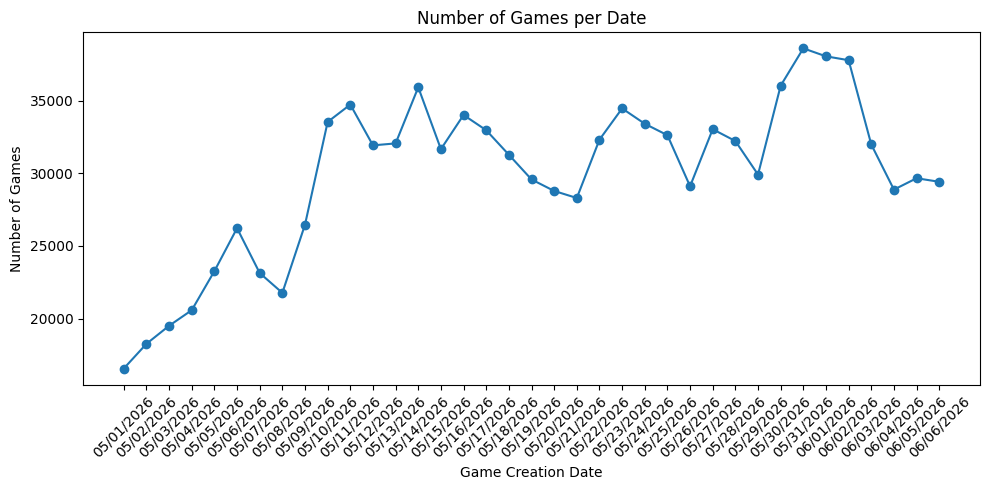

In [7]:
games_per_date = (
    first_rows
    .groupby("gameCreationDate")
    .agg(n_games=("gameId", "count"))
    .reset_index()
    .sort_values("gameCreationDate")
)

plt.figure(figsize=(10, 5))
plt.plot(games_per_date["gameCreationDate"], games_per_date["n_games"], marker="o")
plt.title("Number of Games per Date")
plt.xlabel("Game Creation Date")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

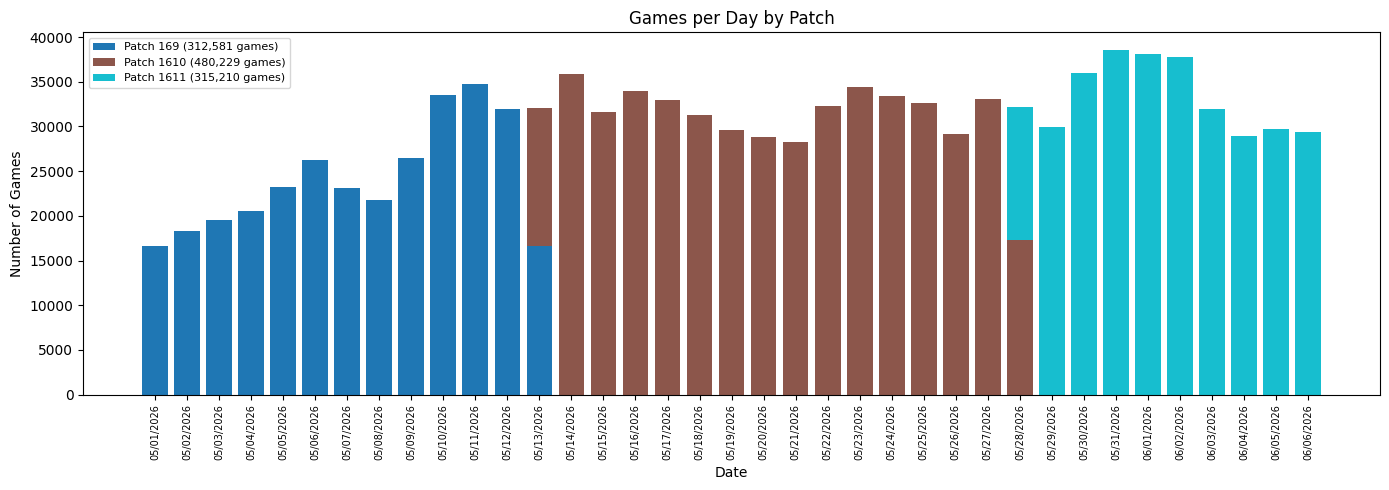

In [8]:
games_per_date_patch = (
    first_rows.groupby(['gameCreationDate', 'patch'])
    .size()
    .reset_index(name='n_games')
    .sort_values(['gameCreationDate', 'patch'])
)

patches = sorted(games_per_date_patch['patch'].unique())
dates = sorted(games_per_date_patch['gameCreationDate'].unique())

colors = cm.tab10(np.linspace(0, 1, len(patches)))
patch_color = {p: colors[i] for i, p in enumerate(patches)}

patch_totals = games_per_date_patch.groupby('patch')['n_games'].sum()

fig, ax = plt.subplots(figsize=(14, 5))

bottoms = np.zeros(len(dates))
date_index = {d: i for i, d in enumerate(dates)}

for patch in patches:
    patch_data = games_per_date_patch[games_per_date_patch['patch'] == patch]
    heights = np.zeros(len(dates))
    for _, row in patch_data.iterrows():
        heights[date_index[row['gameCreationDate']]] = row['n_games']
    label = f"Patch {patch} ({patch_totals[patch]:,} games)"
    ax.bar(range(len(dates)), heights, bottom=bottoms,
           color=patch_color[patch], label=label)
    bottoms += heights

ax.set_xticks(range(len(dates)))
ax.set_xticklabels(dates, rotation=90, fontsize=7)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Games')
ax.set_title('Games per Day by Patch')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## A Note on Dataset Size

Over a month, we have collected 912,256 games. Depending on your machine, loading and processing the entire dataset may be slow,
run out of memory, or cause your kernel to crash.

This is one of the core challenges this course is designed to address: **how can we make the best predictions available, if we cannot train our model on the full dataset?**

---

### Why This Matters in MLOps

In production, data scientists rarely work with the full dataset on a local machine.
They work with samples, subsets, or purpose-built slices of data during development,
and only run full-scale jobs on cloud infrastructure or distributed systems.
Knowing *how* to subset your data and understanding the consequences of each choice
is a professional skill.

---

### Three Approaches to Reducing Dataset Size

#### 1. Random Sampling
Keep a random fraction of games regardless of when they were played or who played them.

```python
df_sample = df.sample(frac=0.1, random_state=42)  # 10% of games
```

**Tradeoff:** Fast and unbiased, but you lose temporal density.
Early dates may end up with very few games, making cumulative win rate features
unreliable for those days. The patch boundary problem becomes worse.

---

#### 2. Sample Based on Criteria
Keep only games that meet a specific condition, for example, high-skill games only.

```python
df_sample = df[df['tier'].isin(['Master', 'Grandmaster', 'Challenger'])]
```

**Tradeoff:** The resulting model is only valid for that population.
A model trained on Master + games will not generalize well to Diamond or Platinum players.
If you are building a coaching tool for casual players,
Master+ training data is the wrong choice even if it produces cleaner features.

---

#### 3. Keep Only Recent Patches
Keep only the last one or two patches, discarding older history.

```python
recent_patches = sorted(df['patch'].unique())[-2:]
df_sample = df[df['patch'].isin(recent_patches)]
```

**Tradeoff:** The most practically relevant subset for deployment, as the model will reflects the current meta, but you lose the ability to observe cross-patch drift.

---

### What We Will Cover This Semester

Choosing how to sample data is an organizational decision as much as a technical one.
Throughout this course we will revisit this question in several contexts:

- **Feature engineering:** does your sample have enough games per champion to compute reliable win rates?
- **Train/test split:** does your sample cover enough patches to make temporal validation meaningful?
- **Drift monitoring:** does your sample span enough time to observe real distribution shift?
- **Deployment justification:** does your training population match the population the model will serve?

For now, if your machine is struggling, start with the last two patches.
That gives you a manageable dataset while preserving the temporal structure
the course depends on. You can always expand later once your pipeline is working.

In [9]:
thin_df.groupby('patch').size()

,0
patch,
169,3125810
1610,4802290
1611,3152100


In [10]:
# 20260608 JSP I want to run with all of the data for now.
# It modeled slightly better but in order to be consistent with the
# rest of the class I'm going to leave this in.
thin_df = thin_df[thin_df.patch.isin([1610,1611])]

In [11]:
thin_df.groupby('patch').size()

,0
patch,
1610,4802290
1611,3152100


## Evaluating the Model: Accuracy, AUC, and Brier Score

We report three metrics for every model. Each one answers a different question,
and depending on what you are building, some matter more than others.

---

### Accuracy

**What it answers:** How often is the model's binary prediction correct?

Accuracy is the most intuitive metric but the least informative here.
Because blue team wins roughly 50.5% of games, a model that always predicts blue wins
achieves ~50.5% accuracy without learning anything.
**Accuracy is useful as a sanity check but should never be the primary metric
for a near-balanced binary outcome.**

Baseline: 50.5%

(Ambitious) target by the end of the semester: 60%

---

### AUC (Area Under the ROC Curve)

**What it answers:** How well does the model rank outcomes? Does it assign higher
win probability to games that blue actually wins?

AUC measures discrimination: the probability that a randomly chosen blue win
is scored higher than a randomly chosen blue loss.
A random model scores 0.50. A perfect model scores 1.00.
**AUC is the primary metric if you care about ranking or selection.**

Baseline: 0.50

(Ambitious) target by the end of the semester: 0.65

---

### Brier Score

**What it answers:** How accurate are the predicted probabilities?

Brier score is the mean squared error between predicted probability and actual outcome.
Lower is better. A model that always predicts 0.5 scores 0.25, and that is the baseline.
A model that predicts confidently and correctly scores well below 0.25.
A model that predicts confidently and wrongly scores above 0.25 and is actively harmful.
**Brier score is the primary metric if you care about calibration (how much to trust the number).**

Baseline: 0.250

(Ambitious) target by the end of the semester: 0.235

---

## Calibration

A model can have decent AUC, meaning it ranks outcomes correctly,
while still being badly miscalibrated. Calibration answers a different question:

**When the model says 70% win probability, does blue actually win 70% of the time?**

A miscalibrated model is dangerous in production. It ranks correctly but the
numbers it reports cannot be trusted as probabilities. For a draft assistant
this means overconfident recommendations. For a betting house it means mispriced odds.

### How to Read a Calibration Curve

A calibration curve plots **predicted probability** on the x-axis against
**actual win rate** on the y-axis, computed within bins of predictions.
A perfectly calibrated model falls exactly on the diagonal.

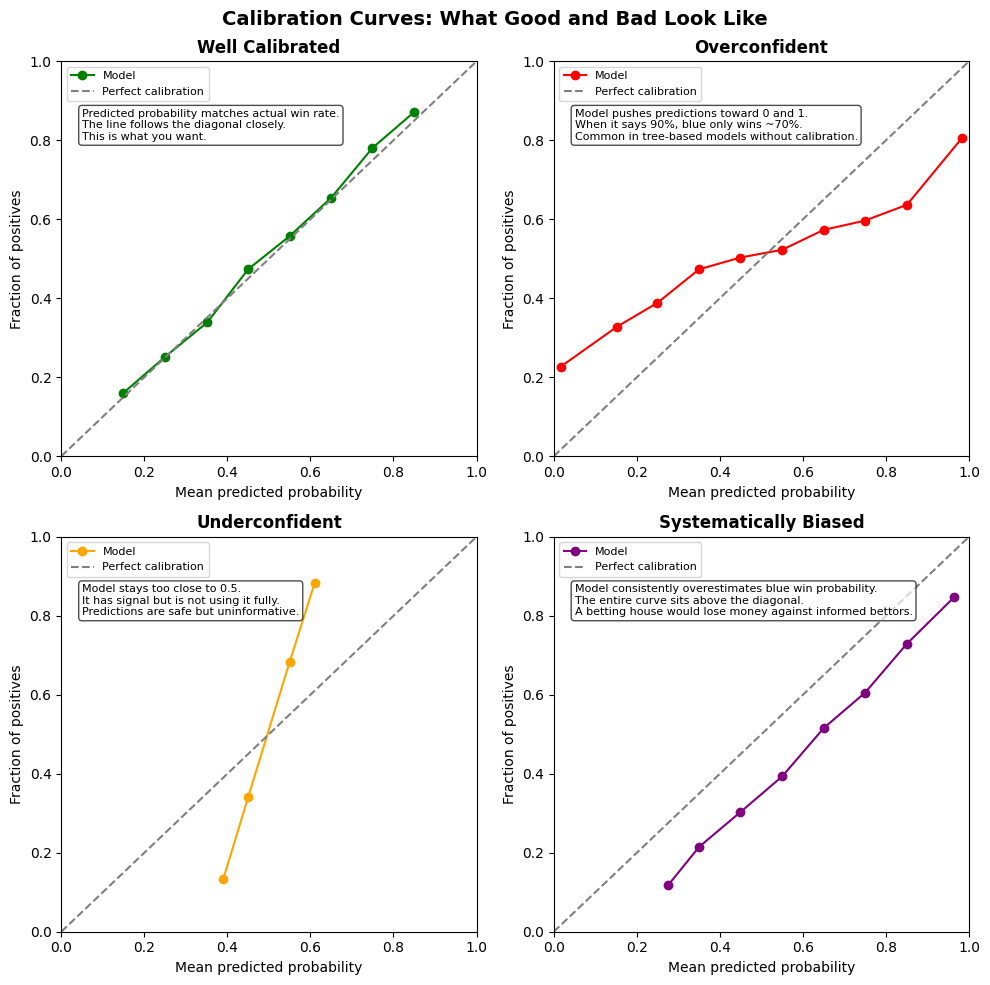

In [12]:
np.random.seed(42)
n = 10000
y_true = np.random.binomial(1, 0.5, n)

# Perfect calibration: generate true probabilities first, then simulate outcomes
p_perfect = np.random.uniform(0.1, 0.9, n)
y_true = np.random.binomial(1, p_perfect, n)

# Overconfident: push predictions toward extremes
p_overconfident = np.clip((p_perfect - 0.5) * 2.5 + 0.5, 0.01, 0.99)

# Underconfident: shrink toward 0.5
p_underconfident = (p_perfect - 0.5) * 0.3 + 0.5

# Systematically biased: shift everything up
p_biased = np.clip(p_perfect + 0.15, 0.01, 0.99)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

cases = [
    (p_perfect,       'Well Calibrated',       'green',
     'Predicted probability matches actual win rate.\nThe line follows the diagonal closely.\nThis is what you want.'),
    (p_overconfident, 'Overconfident',          'red',
     'Model pushes predictions toward 0 and 1.\nWhen it says 90%, blue only wins ~70%.\nCommon in tree-based models without calibration.'),
    (p_underconfident,'Underconfident',         'orange',
     'Model stays too close to 0.5.\nIt has signal but is not using it fully.\nPredictions are safe but uninformative.'),
    (p_biased,        'Systematically Biased',  'purple',
     'Model consistently overestimates blue win probability.\nThe entire curve sits above the diagonal.\nA betting house would lose money against informed bettors.'),
]

for ax, (probs, title, color, description) in zip(axes.flatten(), cases):
    frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', color=color, label='Model')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.text(0.05, 0.88, description, transform=ax.transAxes,
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Calibration Curves: What Good and Bad Look Like', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### What Each Pattern Means for Your Use Case

| Pattern | Coaching Tool | Draft Assistant | Betting House |
|---|---|---|---|
| Well calibrated | Fine | Fine | Required |
| Overconfident | Misleading advice | Overstates edges | Exploitable by bettors |
| Underconfident | Too conservative | Undersells good picks | Leaves money on table |
| Systematically biased | Consistently wrong direction | Favors one side | Immediate financial risk |

---

### How to Check Your Model

```python
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker='o', label='Model')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Your Model — Calibration Curve')
ax.legend()
plt.tight_layout()
plt.show()
```

Logistic regression is generally well calibrated out of the box.
If you switch to a tree-based model later in the course, expect overconfidence
and consider applying `CalibratedClassifierCV` from sklearn to correct it.

## Which Metric Matters for Your Use Case?

The main two business cases for this dataset that you identified were a draft assistant and a betting house.
Each problem might have a different target metric to optimize!


### Draft Assistant

A draft assistant recommends champion picks during the drafting phase,
before the game starts. It might suggest: *"picking champion X here gives your
team a 4% higher predicted win rate than champion Y."*

**Most relevant: AUC**

AUC matters because the assistant needs to correctly rank champion choices —
the best pick should score highest. But Brier score also matters here because
the assistant is communicating a probability difference to the user.
If the model says *"this pick improves your win chance by 8%"* but the true
improvement is 1%, users will overtrust it and make worse decisions.

A well-calibrated model (low Brier score) gives the draft assistant credibility.
An overconfident model erodes trust quickly once users notice the predictions
do not match outcomes.

---

### Gambling / Betting House

A betting house prices odds based on predicted win probabilities.
If the model says blue wins with 60% probability, the house sets odds accordingly
and accepts bets on both sides.

**Most relevant: Brier Score**

This is the highest-stakes calibration context. A miscalibrated model misprices risk. If the model
systematically overestimates blue win probability, bettors who know this
can exploit the mispricing and the house loses money.

AUC is less relevant here because ranking alone is not enough:
the house needs to know *by how much* one team is favored,
not just *which* team is more likely to win.
Accuracy is essentially irrelevant for pricing purposes.

A betting house would also care about **calibration curves** to verify that a predicted 70%
win rate actually corresponds to ~70% of games won in the data.


## Creating a Feature

### Champion Win Rate

In [13]:
champ_wr = (
    thin_df.groupby(['gameCreationDate', 'championId'])['win']
    .agg(games='size', win_rate='mean')
    .reset_index()
)
champ_wr.sort_values(by=['gameCreationDate','championId'])

,gameCreationDate,championId,games,win_rate
0,05/13/2026,1,536,0.466418
1,05/13/2026,2,506,0.494071
2,05/13/2026,3,793,0.484237
3,05/13/2026,4,596,0.494966
4,05/13/2026,5,1426,0.469846
...,...,...,...,...
4295,06/06/2026,901,3014,0.500000
4296,06/06/2026,902,1464,0.500000
4297,06/06/2026,904,895,0.478212
4298,06/06/2026,910,1466,0.497271


In [14]:
merged = thin_df.merge(
    champ_wr[['gameCreationDate', 'championId','games','win_rate']],
    on=['gameCreationDate', 'championId'],
    how='left'
)
merged.head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin,games,win_rate
0,5576347036,1780789359000,06/06/2026,1611,Bronze I,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,r5,UTILITY,201,317.0,551.0,0,1,1065,0.492019
1,5576347036,1780789359000,06/06/2026,1611,Bronze I,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,r4,BOTTOM,51,1140.0,53620.0,0,1,5631,0.480376
2,5576347036,1780789359000,06/06/2026,1611,Bronze I,LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...,r3,MIDDLE,39,838.0,25590.0,0,1,1695,0.494985
3,5576347036,1780789359000,06/06/2026,1611,Bronze I,3JHxmwD0ISAgOfCHQiphzSkAEqrCYvLFTjaMAXR10JJYn_...,r2,JUNGLE,54,773.0,26785.0,0,1,2721,0.501654
4,5576347036,1780789359000,06/06/2026,1611,Bronze I,nYK1rHBtZJpVl24I8YqYeg53oV4rmoFn0GmBm6uVDIjVBw...,r1,TOP,6,733.0,56443.0,0,1,1283,0.506625


In [15]:
slot_order = ['b1', 'b2', 'b3', 'b4', 'b5', 'r1', 'r2', 'r3', 'r4', 'r5']
wide_frames = []

for col in ['games','win_rate']:
    wide = merged.pivot_table(
        index='gameId',
        columns='player_slot',
        values=col,
        aggfunc='first'
    )
    wide = wide[slot_order]
    wide.columns = [f"{s}_{col}" for s in slot_order]
    wide_frames.append(wide)

wide_df = pd.concat(wide_frames, axis=1).reset_index()

wide_df.head(5)

,gameId,b1_games,b2_games,b3_games,b4_games,b5_games,r1_games,r2_games,r3_games,r4_games,r5_games,b1_win_rate,b2_win_rate,b3_win_rate,b4_win_rate,b5_win_rate,r1_win_rate,r2_win_rate,r3_win_rate,r4_win_rate,r5_win_rate
0,5559427826,590,1196,1697,232,1507,1286,1396,630,3104,1428,0.567797,0.485786,0.516794,0.560345,0.499668,0.494557,0.501433,0.495238,0.494201,0.457283
1,5559427860,939,537,1089,2451,639,440,720,418,3104,821,0.499468,0.506518,0.464646,0.503468,0.491393,0.490909,0.468056,0.488038,0.494201,0.509135
2,5559427862,823,1899,1148,807,444,1382,1396,2451,3967,1320,0.422843,0.508689,0.486934,0.483271,0.511261,0.493488,0.522206,0.503468,0.535417,0.468939
3,5559427905,1630,1396,882,733,688,1382,1899,1740,2091,1507,0.514110,0.501433,0.520408,0.517053,0.473837,0.493488,0.508689,0.500575,0.484457,0.499668
4,5559427915,651,683,793,947,1320,653,853,1690,1116,2324,0.471582,0.500732,0.484237,0.496304,0.468939,0.513017,0.538101,0.528402,0.491039,0.527108


In [16]:
games_df = thin_df[['gameId','gameCreation','gameCreationDate','patch','tier','bwin']].drop_duplicates(subset='gameId')
games_df = games_df.merge(wide_df, on='gameId', how='left')
games_df.head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,bwin,b1_games,b2_games,b3_games,b4_games,b5_games,r1_games,r2_games,r3_games,r4_games,r5_games,b1_win_rate,b2_win_rate,b3_win_rate,b4_win_rate,b5_win_rate,r1_win_rate,r2_win_rate,r3_win_rate,r4_win_rate,r5_win_rate
0,5576347036,1780789359000,06/06/2026,1611,Bronze I,1,2321,1017,2360,4438,924,1283,2721,1695,5631,1065,0.524343,0.507375,0.519492,0.507886,0.482684,0.506625,0.501654,0.494985,0.480376,0.492019
1,5576346899,1780789323000,06/06/2026,1611,Platinum III,1,766,2753,910,4438,5287,789,1007,3426,5042,4612,0.473890,0.519797,0.503297,0.507886,0.515793,0.476553,0.522344,0.505254,0.500595,0.529055
2,5576346837,1780789323000,06/06/2026,1611,Platinum IV,1,3562,2894,1109,4438,993,2225,789,3426,5042,1466,0.493262,0.492744,0.492335,0.507886,0.494461,0.511011,0.489227,0.505254,0.500595,0.497271
3,5576346425,1780789452000,06/06/2026,1611,Master +,0,1291,2828,1936,1720,5408,789,1070,1469,538,1269,0.504260,0.496110,0.499483,0.506395,0.522744,0.476553,0.478505,0.496256,0.455390,0.471237
4,5576346261,1780789398000,06/06/2026,1611,Platinum IV,1,890,601,2934,3074,4612,3484,2404,2361,690,1720,0.460674,0.477537,0.505453,0.460638,0.529055,0.533582,0.509567,0.505718,0.494203,0.506395


In [17]:
print("Percentage of wins for blue team: ", round(100*float(games_df['bwin'].mean()),2), "%")

Percentage of wins for blue team:  49.59 %


In [18]:
for col in ['games','win_rate']:
    blue_cols = [f"b{i}_{col}" for i in range(1, 6)]
    red_cols = [f"r{i}_{col}" for i in range(1, 6)]
    games_df[f"blue_avg_{col}"] = games_df[blue_cols].mean(axis=1)
    games_df[f"red_avg_{col}"] = games_df[red_cols].mean(axis=1)
    games_df[f"diff_{col}"] = games_df[f"blue_avg_{col}"] - games_df[f"red_avg_{col}"]

In [19]:
games_df = games_df[['gameId','diff_win_rate','diff_games','bwin']]

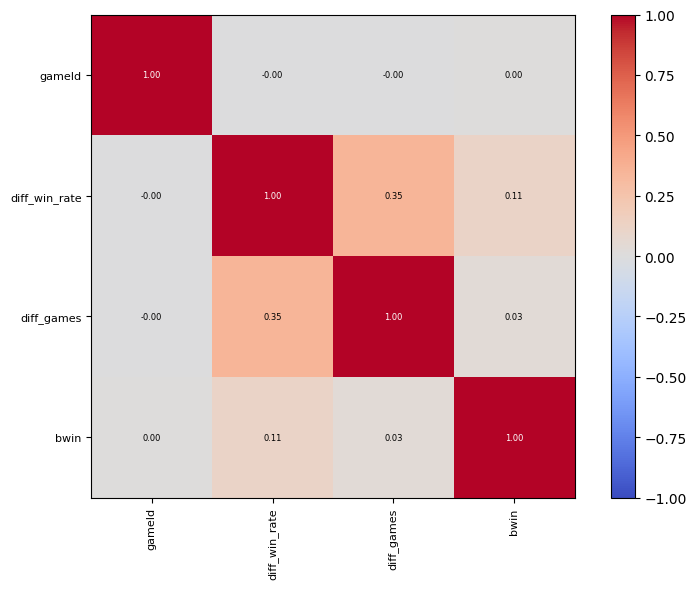

In [20]:
corr_matrix = games_df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(val) > 0.5 else 'black')

plt.tight_layout()
plt.show()

In [21]:
feature_cols = [c for c in games_df.columns if c not in ['gameId', 'gameCreation', 'gameCreationDate', 'patch', 'tier', 'bwin']]

X = games_df[feature_cols].fillna(0)
y = games_df['bwin']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

preds = model.predict(X)
proba = model.predict_proba(X)[:, 1]

print(f"Accuracy : {accuracy_score(y, preds):.4f}")
print(f"AUC      : {roc_auc_score(y, proba):.4f}")
print(f"Brier    : {brier_score_loss(y, proba):.4f}")

Accuracy : 0.5458
AUC      : 0.5644
Brier    : 0.2468


### What went wrong?

#### 1. Data leakage in the win rate computation

`champ_wr` was computed by grouping the full dataset by `gameCreationDate` and `championId`, then taking the mean of `win`.
That means a game played on May 5th contributed to the May 5th win rate, which was then merged back and used as a feature to predict that same game.

**The model partially saw the answers before predicting.**

Fix — shift the lookup forward by one day before merging:

```python
champ_wr['available_on'] = champ_wr['gameCreationDate'] + pd.Timedelta(days=1)
```

#### 2. Only yesterday's data — not all prior days

Even after the one-day shift, merging on `gameCreationDate` means each game gets exactly one day of history.
The correct construction is cumulative: for each game, use all prior days in the patch, not just the previous one.

#### 3. No train/test split

The model was fit and evaluated on the same rows.
Even with clean features, this evaluation is meaningless.
The correct approach (Week 4) is a patch-based temporal split — the 80th percentile of `gameCreation` within each patch as the cutoff.

| Issue | Effect | Fix |
|---|---|---|
| Win rate includes current day | Metrics inflated | +1 day shift before merge |
| Only one day of history | Features sparse and noisy | Cumulative window over patch |
| No train/test split | Evaluation unreliable | Patch-based temporal split (Week 4) |

### (Updated) Champion Win Rate

In [22]:
thin_df['gameCreationDate'] = pd.to_datetime(thin_df['gameCreationDate'])

champ_wr = (
    thin_df.groupby(['patch', 'gameCreationDate', 'championId'])['win']
    .agg(games='size', wins='sum')
    .reset_index()
    .sort_values(by=['patch', 'championId', 'gameCreationDate'])
)
champ_wr.head(5)

,patch,gameCreationDate,championId,games,wins
0,1610,2026-05-13,1,536,250
172,1610,2026-05-14,1,1286,685
344,1610,2026-05-15,1,1051,533
516,1610,2026-05-16,1,1199,610
688,1610,2026-05-17,1,1192,611


In [23]:
champ_wr['cumulative_games'] = (
    champ_wr.groupby(['patch', 'championId'])['games'].cumsum()
)

champ_wr['cumulative_wins'] = (
    champ_wr.groupby(['patch', 'championId'])['wins'].cumsum()
)

champ_wr['cumulative_wr'] = champ_wr['cumulative_wins'] / champ_wr['cumulative_games']

champ_wr.head(5)

,patch,gameCreationDate,championId,games,wins,cumulative_games,cumulative_wins,cumulative_wr
0,1610,2026-05-13,1,536,250,536,250,0.466418
172,1610,2026-05-14,1,1286,685,1822,935,0.513172
344,1610,2026-05-15,1,1051,533,2873,1468,0.510964
516,1610,2026-05-16,1,1199,610,4072,2078,0.510314
688,1610,2026-05-17,1,1192,611,5264,2689,0.510828


In [24]:
champ_wr['available_on'] = champ_wr['gameCreationDate'] + pd.Timedelta(days=1)
champ_wr['patch_on'] = champ_wr['patch']
champ_wr.head(5)

,patch,gameCreationDate,championId,games,wins,cumulative_games,cumulative_wins,cumulative_wr,available_on,patch_on
0,1610,2026-05-13,1,536,250,536,250,0.466418,2026-05-14,1610
172,1610,2026-05-14,1,1286,685,1822,935,0.513172,2026-05-15,1610
344,1610,2026-05-15,1,1051,533,2873,1468,0.510964,2026-05-16,1610
516,1610,2026-05-16,1,1199,610,4072,2078,0.510314,2026-05-17,1610
688,1610,2026-05-17,1,1192,611,5264,2689,0.510828,2026-05-18,1610


In [25]:
merged = thin_df.merge(
    champ_wr[['available_on', 'patch_on', 'championId', 'cumulative_games', 'cumulative_wr']],
    left_on=['gameCreationDate', 'patch', 'championId'],
    right_on=['available_on', 'patch_on', 'championId'],
    how='left'
)

merged.head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin,available_on,patch_on,cumulative_games,cumulative_wr
0,5576347036,1780789359000,2026-06-06,1611,Bronze I,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,r5,UTILITY,201,317.0,551.0,0,1,2026-06-06,1611.0,10094.0,0.494947
1,5576347036,1780789359000,2026-06-06,1611,Bronze I,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,r4,BOTTOM,51,1140.0,53620.0,0,1,2026-06-06,1611.0,56318.0,0.493590
2,5576347036,1780789359000,2026-06-06,1611,Bronze I,LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...,r3,MIDDLE,39,838.0,25590.0,0,1,2026-06-06,1611.0,17053.0,0.495279
3,5576347036,1780789359000,2026-06-06,1611,Bronze I,3JHxmwD0ISAgOfCHQiphzSkAEqrCYvLFTjaMAXR10JJYn_...,r2,JUNGLE,54,773.0,26785.0,0,1,2026-06-06,1611.0,27240.0,0.507195
4,5576347036,1780789359000,2026-06-06,1611,Bronze I,nYK1rHBtZJpVl24I8YqYeg53oV4rmoFn0GmBm6uVDIjVBw...,r1,TOP,6,733.0,56443.0,0,1,2026-06-06,1611.0,12458.0,0.514529


In [26]:
slot_order = ['b1', 'b2', 'b3', 'b4', 'b5', 'r1', 'r2', 'r3', 'r4', 'r5']
wide_frames = []

for col in ['cumulative_games','cumulative_wr']:
    wide = merged.pivot_table(
        index='gameId',
        columns='player_slot',
        values=col,
        aggfunc='first'
    )
    wide = wide[slot_order]
    wide.columns = [f"{s}_{col}" for s in slot_order]
    wide_frames.append(wide)

wide_df = pd.concat(wide_frames, axis=1).reset_index()

wide_df.head(5)

,gameId,b1_cumulative_games,b2_cumulative_games,b3_cumulative_games,b4_cumulative_games,b5_cumulative_games,r1_cumulative_games,r2_cumulative_games,r3_cumulative_games,r4_cumulative_games,r5_cumulative_games,b1_cumulative_wr,b2_cumulative_wr,b3_cumulative_wr,b4_cumulative_wr,b5_cumulative_wr,r1_cumulative_wr,r2_cumulative_wr,r3_cumulative_wr,r4_cumulative_wr,r5_cumulative_wr
0,5559723976,654.0,683.0,1085.0,1630.0,2233.0,630.0,498.0,596.0,3104.0,739.0,0.487768,0.500732,0.465438,0.514110,0.518585,0.492063,0.495984,0.494966,0.494201,0.493911
1,5559723991,1697.0,1072.0,492.0,3104.0,2324.0,876.0,1196.0,1104.0,733.0,890.0,0.516794,0.526119,0.497967,0.494201,0.527108,0.488584,0.485786,0.551630,0.517053,0.534831
2,5559724005,1286.0,732.0,1072.0,438.0,688.0,537.0,1233.0,2233.0,461.0,1320.0,0.494557,0.479508,0.526119,0.531963,0.473837,0.504655,0.506083,0.518585,0.490239,0.468939
3,5559724012,970.0,853.0,596.0,830.0,1382.0,1697.0,406.0,821.0,2019.0,405.0,0.494845,0.538101,0.491611,0.479518,0.495658,0.516794,0.512315,0.509135,0.498762,0.471605
4,5559724177,590.0,1426.0,1507.0,1630.0,1320.0,1116.0,1559.0,1665.0,3967.0,2451.0,0.567797,0.469846,0.499668,0.514110,0.468939,0.491039,0.499038,0.502102,0.535417,0.503468


In [27]:
games_df = thin_df[['gameId','gameCreation','gameCreationDate','patch','tier','bwin']].drop_duplicates(subset='gameId')
games_df = games_df.merge(wide_df, on='gameId', how='left')
games_df.head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,bwin,b1_cumulative_games,b2_cumulative_games,b3_cumulative_games,b4_cumulative_games,b5_cumulative_games,r1_cumulative_games,r2_cumulative_games,r3_cumulative_games,r4_cumulative_games,r5_cumulative_games,b1_cumulative_wr,b2_cumulative_wr,b3_cumulative_wr,b4_cumulative_wr,b5_cumulative_wr,r1_cumulative_wr,r2_cumulative_wr,r3_cumulative_wr,r4_cumulative_wr,r5_cumulative_wr
0,5576347036,1780789359000,2026-06-06,1611,Bronze I,1,23340.0,8669.0,22537.0,44078.0,8888.0,12458.0,27240.0,17053.0,56318.0,10094.0,0.522237,0.499135,0.521409,0.508303,0.516539,0.514529,0.507195,0.495279,0.493590,0.494947
1,5576346899,1780789323000,2026-06-06,1611,Platinum III,1,7260.0,26210.0,7519.0,44078.0,51168.0,7603.0,10016.0,36147.0,49835.0,43767.0,0.474793,0.510378,0.510706,0.508303,0.507446,0.481257,0.519669,0.502310,0.502639,0.515982
2,5576346837,1780789323000,2026-06-06,1611,Platinum IV,1,34901.0,27036.0,10324.0,44078.0,8841.0,21791.0,8554.0,36147.0,49835.0,13977.0,0.498267,0.501775,0.503681,0.508303,0.497116,0.518333,0.491115,0.502310,0.502639,0.495457
3,5576346425,1780789452000,2026-06-06,1611,Master +,0,12854.0,28301.0,18734.0,15949.0,44130.0,7603.0,10345.0,14340.0,4607.0,12176.0,0.503034,0.497650,0.492634,0.507681,0.520168,0.481257,0.479942,0.503138,0.471022,0.494251
4,5576346261,1780789398000,2026-06-06,1611,Platinum IV,1,7744.0,5415.0,28573.0,29803.0,43767.0,33283.0,24012.0,22016.0,7565.0,15949.0,0.468492,0.490305,0.510447,0.459383,0.515982,0.514527,0.491171,0.514217,0.494646,0.507681


In [28]:
print("Percentage of wins for blue team: ", round(100*float(games_df['bwin'].mean()),2), "%")

Percentage of wins for blue team:  49.59 %


In [29]:
for col in ['cumulative_games','cumulative_wr']:
    blue_cols = [f"b{i}_{col}" for i in range(1, 6)]
    red_cols = [f"r{i}_{col}" for i in range(1, 6)]
    games_df[f"blue_avg_{col}"] = games_df[blue_cols].mean(axis=1)
    games_df[f"red_avg_{col}"] = games_df[red_cols].mean(axis=1)
    games_df[f"diff_{col}"] = games_df[f"blue_avg_{col}"] - games_df[f"red_avg_{col}"]

games_df = games_df[['gameId', 'gameCreation', 'patch', 'diff_cumulative_games','diff_cumulative_wr','bwin']]
games_df.head(5)

,gameId,gameCreation,patch,diff_cumulative_games,diff_cumulative_wr,bwin
0,5576347036,1780789359000,1611,-3130.2,0.012416,1
1,5576346899,1780789323000,1611,-2226.6,-0.002046,1
2,5576346837,1780789323000,1611,-1024.8,-0.000142,1
3,5576346425,1780789452000,1611,14179.4,0.018311,0
4,5576346261,1780789398000,1611,2495.4,-0.015527,1


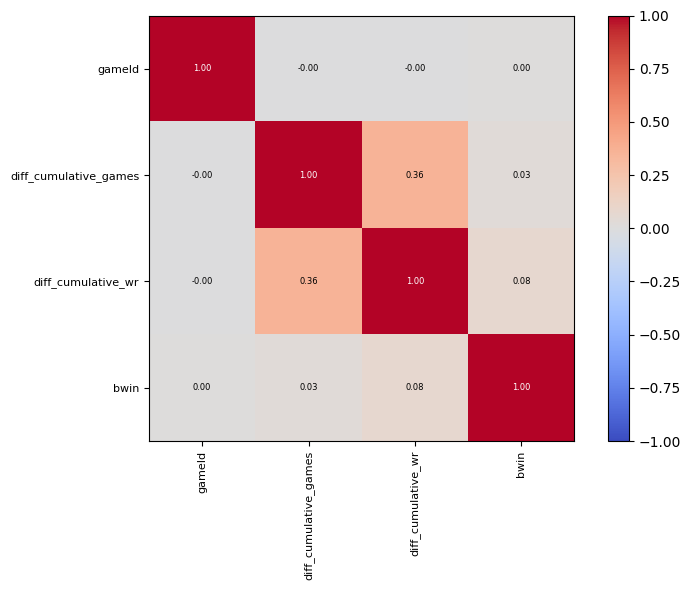

In [30]:
drop_cols = ['gameCreation', 'patch']
corr_matrix = games_df.drop(columns=drop_cols, errors='ignore').corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(val) > 0.5 else 'black')

plt.tight_layout()
plt.show()

In [31]:
feature_cols = [c for c in games_df.columns if c not in ['gameId', 'gameCreation', 'gameCreationDate', 'patch', 'tier', 'bwin']]

cutoffs = games_df.groupby('patch')['gameCreation'].quantile(0.8)
games_df['cutoff'] = games_df['patch'].map(cutoffs)
train = games_df[games_df['gameCreation'] <= games_df['cutoff']]
test  = games_df[games_df['gameCreation'] >  games_df['cutoff']]

X_train = train[feature_cols].fillna(0)
y_train = train['bwin']
X_test  = test[feature_cols].fillna(0)
y_test  = test['bwin']

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"Accuracy   : {accuracy_score(y_test, preds):.4f}")
print(f"AUC        : {roc_auc_score(y_test, proba):.4f}")
print(f"Brier      : {brier_score_loss(y_test, proba):.4f}")

Train size : 636,351
Test size  : 159,088
Accuracy   : 0.5353
AUC        : 0.5483
Brier      : 0.2483


### What is better now?

#### 1. Win rate no longer leaks
`available_on` ensures each game only sees champion win rates computed from games played on prior days.
The model is no longer partially predicting outcomes it already saw.

#### 2. Cumulative history within patch
Instead of one day of history, each game now accumulates all prior days in the same patch.
A champion played on day 10 of a patch gets 9 days of evidence, not just yesterday.

#### 3. Proper train/test split
The model is now fit on the first 80% of each patch and evaluated on the remaining 20%.
The metrics reported are actual out-of-sample estimates.

---

### What is still weak?

#### 1. Champion win rate is a weak feature
Champion pick explains some variance in outcomes, but player skill explains far more.
A good player on a weak champion will often beat a bad player on a strong champion.
AUC will likely land between 0.52 and 0.56 — real signal, but modest.

#### 2. First days of a patch are unreliable
On day one or two of a new patch, cumulative win rates are computed from very few games.
A champion with 3 games and 2 wins has a 67% win rate — statistically meaningless.
A minimum games threshold (e.g. `cumulative_games >= 50`) before trusting the feature is needed.

#### 3. Win rates shift across patches
A champion buffed or nerfed between patches will have a different true win rate.
Using cumulative history scoped to the current patch partially addresses this,
but early patch data is still noisy before the meta stabilizes.

#### 4. No player-level signal yet
The model knows nothing about who is playing the champions — only which champions are picked.
Recent player win rate, LP slope, role consistency, and streak are all stronger predictors
and are the natural next step.

| What improved | What remains |
|---|---|
| No same-day leakage | Champion win rate is a weak signal |
| Full patch history accumulated | First days of patch are unreliable |
| Out-of-sample evaluation | No minimum games threshold |
| Patch-scoped features | No player-level features yet |

### Bayesian Win Rate

Raw cumulative win rate has a small-sample problem: a champion with 3 games and 2 wins
shows a 67% win rate, which is statistically meaningless but will be treated as signal by the model.

Imagine Amazon: you are considering two similar products. Product A has 10 5 star reviews, while product B has an average of 4.7 stars over 1200 reviews. You probably would go with product B, right?

What if product C has an average of 4.9 over 250 reviews? The solution for it is called **Bayesian Smoothing**


**Bayesian win rate** solves this by shrinking the estimate toward a prior — the global average
win rate across all champions — when sample size is small. As evidence accumulates, the estimate
converges to the empirical rate.

The formula is:

$$\hat{p} = \frac{\text{cumulative wins} + \alpha \cdot \mu}{\text{cumulative games} + \alpha}$$

Where:
- $\mu$ is the global prior win rate (roughly 0.5)
- $\alpha$ is the strength of the prior — how many "ghost games" worth of evidence to add
- When `cumulative_games` is small, the estimate stays close to $\mu$
- When `cumulative_games` is large, the estimate converges to the empirical rate

A reasonable starting value for $\alpha$ is 50 — meaning the prior is worth 50 games of evidence.

In [32]:
champ_role_wr = (
    thin_df.groupby(['patch', 'teamPosition','gameCreationDate', 'championId'])['win']
    .agg(games='size', wins='sum')
    .reset_index()
    .sort_values(by=['patch', 'championId', 'gameCreationDate'])
)

champ_role_wr['cumulative_games'] = (
    champ_role_wr.groupby(['patch', 'championId'])['games'].cumsum()
)

champ_role_wr['cumulative_wins'] = (
    champ_role_wr.groupby(['patch', 'championId'])['wins'].cumsum()
)

champ_role_wr['cumulative_wr'] = champ_role_wr['cumulative_wins'] / champ_role_wr['cumulative_games']

champ_role_wr['available_on'] = champ_role_wr['gameCreationDate'] + pd.Timedelta(days=1)

champ_role_wr.head(5)

,patch,teamPosition,gameCreationDate,championId,games,wins,cumulative_games,cumulative_wins,cumulative_wr,available_on
0,1610,BOTTOM,2026-05-13,1,5,3,5,3,0.600000,2026-05-14
2496,1610,JUNGLE,2026-05-13,1,2,0,7,3,0.428571,2026-05-14
4814,1610,MIDDLE,2026-05-13,1,431,205,438,208,0.474886,2026-05-14
7521,1610,TOP,2026-05-13,1,20,9,458,217,0.473799,2026-05-14
10231,1610,UTILITY,2026-05-13,1,78,33,536,250,0.466418,2026-05-14


In [33]:
prior_games = 50
prior_wr = 0.5

champ_role_wr['bayesian_wr'] = (
    (champ_role_wr['cumulative_wins'] + prior_games * prior_wr) /
    (champ_role_wr['cumulative_games'] + prior_games)
)

champ_role_wr.head(5)

,patch,teamPosition,gameCreationDate,championId,games,wins,cumulative_games,cumulative_wins,cumulative_wr,available_on,bayesian_wr
0,1610,BOTTOM,2026-05-13,1,5,3,5,3,0.600000,2026-05-14,0.509091
2496,1610,JUNGLE,2026-05-13,1,2,0,7,3,0.428571,2026-05-14,0.491228
4814,1610,MIDDLE,2026-05-13,1,431,205,438,208,0.474886,2026-05-14,0.477459
7521,1610,TOP,2026-05-13,1,20,9,458,217,0.473799,2026-05-14,0.476378
10231,1610,UTILITY,2026-05-13,1,78,33,536,250,0.466418,2026-05-14,0.469283


In [34]:
champ_role_wr[champ_role_wr.cumulative_wr == 1].head(10)

,patch,teamPosition,gameCreationDate,championId,games,wins,cumulative_games,cumulative_wins,cumulative_wr,available_on,bayesian_wr
15,1610,BOTTOM,2026-05-13,16,2,2,2,2,1.0,2026-05-14,0.519231
18,1610,BOTTOM,2026-05-13,19,1,1,1,1,1.0,2026-05-14,0.509804
35,1610,BOTTOM,2026-05-13,38,1,1,1,1,1.0,2026-05-14,0.509804
37,1610,BOTTOM,2026-05-13,41,1,1,1,1,1.0,2026-05-14,0.509804
46,1610,BOTTOM,2026-05-13,56,1,1,1,1,1.0,2026-05-14,0.509804
56,1610,BOTTOM,2026-05-13,72,1,1,1,1,1.0,2026-05-14,0.509804
78,1610,BOTTOM,2026-05-13,106,1,1,1,1,1.0,2026-05-14,0.509804
87,1610,BOTTOM,2026-05-13,122,1,1,1,1,1.0,2026-05-14,0.509804
134,1610,BOTTOM,2026-05-13,875,2,2,2,2,1.0,2026-05-14,0.519231
12918,1611,BOTTOM,2026-05-28,5,8,8,8,8,1.0,2026-05-29,0.568966


In [35]:
champ_role_wr.sort_values(by='bayesian_wr', ascending=False).head(10)

,patch,teamPosition,gameCreationDate,championId,games,wins,cumulative_games,cumulative_wins,cumulative_wr,available_on,bayesian_wr
14605,1611,JUNGLE,2026-05-28,266,114,70,115,71,0.617391,2026-05-29,0.581818
2519,1610,JUNGLE,2026-05-13,31,103,63,110,68,0.618182,2026-05-14,0.581250
14521,1611,JUNGLE,2026-05-28,25,48,30,69,44,0.637681,2026-05-29,0.579832
99,1610,BOTTOM,2026-05-13,157,221,131,221,131,0.592760,2026-05-14,0.575646
2593,1610,JUNGLE,2026-05-13,157,2,1,223,132,0.591928,2026-05-14,0.575092
4840,1610,MIDDLE,2026-05-13,27,44,29,74,46,0.621622,2026-05-14,0.572581
4844,1610,MIDDLE,2026-05-13,31,137,77,247,145,0.587045,2026-05-14,0.572391
40,1610,BOTTOM,2026-05-13,45,185,109,185,109,0.589189,2026-05-14,0.570213
12918,1611,BOTTOM,2026-05-28,5,8,8,8,8,1.000000,2026-05-29,0.568966
2530,1610,JUNGLE,2026-05-13,45,1,0,186,109,0.586022,2026-05-14,0.567797


A champion with 3 games and 3 wins has `cumulative_wr = 1.0` — but this is noise, not signal.
The two cells below demonstrate the effect of Bayesian smoothing:

- The first shows all rows where `cumulative_wr == 1`. These are statistically meaningless.
- The second sorts by `bayesian_wr` instead. Champions with few games get pulled toward 0.5,
  so only champions with both high win rate **and** enough games rise to the top.

This is the core intuition: **more games = more trust**. The prior is worth `α` ghost games.
A champion with 3 real games is dominated by the prior. A champion with 5,000 games
has effectively overwhelmed it.

### First Day of Patch

In [36]:
thin_df['patch'] = thin_df['patch'].astype(int)
champ_wr['patch_on'] = champ_wr['patch_on'].astype(int)

In [37]:
merged = thin_df.merge(
    champ_wr[['available_on', 'patch_on', 'championId', 'cumulative_games', 'cumulative_wins', 'cumulative_wr']],
    left_on=['gameCreationDate', 'patch', 'championId'],
    right_on=['available_on', 'patch_on', 'championId'],
    how='left'
)
merged.head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin,available_on,patch_on,cumulative_games,cumulative_wins,cumulative_wr
0,5576347036,1780789359000,2026-06-06,1611,Bronze I,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,r5,UTILITY,201,317.0,551.0,0,1,2026-06-06,1611.0,10094.0,4996.0,0.494947
1,5576347036,1780789359000,2026-06-06,1611,Bronze I,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,r4,BOTTOM,51,1140.0,53620.0,0,1,2026-06-06,1611.0,56318.0,27798.0,0.493590
2,5576347036,1780789359000,2026-06-06,1611,Bronze I,LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...,r3,MIDDLE,39,838.0,25590.0,0,1,2026-06-06,1611.0,17053.0,8446.0,0.495279
3,5576347036,1780789359000,2026-06-06,1611,Bronze I,3JHxmwD0ISAgOfCHQiphzSkAEqrCYvLFTjaMAXR10JJYn_...,r2,JUNGLE,54,773.0,26785.0,0,1,2026-06-06,1611.0,27240.0,13816.0,0.507195
4,5576347036,1780789359000,2026-06-06,1611,Bronze I,nYK1rHBtZJpVl24I8YqYeg53oV4rmoFn0GmBm6uVDIjVBw...,r1,TOP,6,733.0,56443.0,0,1,2026-06-06,1611.0,12458.0,6410.0,0.514529


In [38]:
merged[(merged['gameCreationDate'] == '2026-05-13') & (merged['patch'] == 1610)].head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin,available_on,patch_on,cumulative_games,cumulative_wins,cumulative_wr
7798300,5559728099,1778716799000,2026-05-13,1610,Diamond III,qPsE0VOE2iaytil55O2wxrf9dd4ycxbU8bSEia0FCeMALz...,r5,UTILITY,412,2564.0,1388852.0,1,0,NaT,NaN,NaN,NaN,NaN
7798301,5559728099,1778716799000,2026-05-13,1610,Diamond III,C0NaX52PSIeuc2CL-YUGlA7o1EbkR1AgSiU8jKFdSJtqmG...,r4,BOTTOM,67,2674.0,143653.0,1,0,NaT,NaN,NaN,NaN,NaN
7798302,5559728099,1778716799000,2026-05-13,1610,Diamond III,nGT-_2hC8bcTwgFOg2IMedwTpOHx54jG_Stj1ronFrcLj8...,r3,MIDDLE,245,2185.0,2694740.0,1,0,NaT,NaN,NaN,NaN,NaN
7798303,5559728099,1778716799000,2026-05-13,1610,Diamond III,vFFAfKmRTO2lWFpbHCy21uGwZWM8bd8ylIeopOdrrcvyO2...,r2,JUNGLE,56,2762.0,845012.0,1,0,NaT,NaN,NaN,NaN,NaN
7798304,5559728099,1778716799000,2026-05-13,1610,Diamond III,P9WNCqZX6j9N_11JVEnHHd_r6g6ibZiEMXYGNTgSF6t7oO...,r1,TOP,17,2638.0,102881.0,1,0,NaT,NaN,NaN,NaN,NaN


In [39]:
champ_wr[(champ_wr.championId == 1) & (champ_wr.patch == 169)]

,patch,gameCreationDate,championId,games,wins,cumulative_games,cumulative_wins,cumulative_wr,available_on,patch_on


In [40]:
last_patch_values = (
    champ_wr.sort_values(['patch', 'championId', 'gameCreationDate'])
    .groupby(['patch', 'championId'])[['cumulative_games', 'cumulative_wins', 'cumulative_wr']]
    .last()
    .reset_index()
)

patch_order = sorted(champ_wr['patch'].unique())
next_patch = {p: patch_order[i+1] for i, p in enumerate(patch_order[:-1])}
last_patch_values['patch'] = last_patch_values['patch'].map(next_patch)
last_patch_values = last_patch_values.dropna(subset=['patch'])
last_patch_values['patch'] = last_patch_values['patch'].astype(champ_wr['patch'].dtype)
last_patch_values = last_patch_values.rename(columns={
    'patch': 'patch_on'
})

last_patch_values['patch_on'] = last_patch_values['patch_on'].astype(int)
last_patch_values.head(5)

,patch_on,championId,cumulative_games,cumulative_wins,cumulative_wr
0,1611,1,16876,8535,0.505748
1,1611,2,15734,7921,0.503432
2,1611,3,22120,11081,0.500949
3,1611,4,21096,10532,0.499242
4,1611,5,43280,22022,0.508826


In [41]:
merged = merged.drop(['cumulative_games','cumulative_wins','cumulative_wr'],axis=1)
merged = merged.merge(
    last_patch_values,
    left_on=['patch', 'championId'],
    right_on = ['patch_on', 'championId'],
    how='left'
)

merged.head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin,available_on,patch_on_x,patch_on_y,cumulative_games,cumulative_wins,cumulative_wr
0,5576347036,1780789359000,2026-06-06,1611,Bronze I,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,r5,UTILITY,201,317.0,551.0,0,1,2026-06-06,1611.0,1611.0,17638.0,8682.0,0.492233
1,5576347036,1780789359000,2026-06-06,1611,Bronze I,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,r4,BOTTOM,51,1140.0,53620.0,0,1,2026-06-06,1611.0,1611.0,94746.0,46972.0,0.495768
2,5576347036,1780789359000,2026-06-06,1611,Bronze I,LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...,r3,MIDDLE,39,838.0,25590.0,0,1,2026-06-06,1611.0,1611.0,27618.0,13715.0,0.496596
3,5576347036,1780789359000,2026-06-06,1611,Bronze I,3JHxmwD0ISAgOfCHQiphzSkAEqrCYvLFTjaMAXR10JJYn_...,r2,JUNGLE,54,773.0,26785.0,0,1,2026-06-06,1611.0,1611.0,46320.0,23528.0,0.507945
4,5576347036,1780789359000,2026-06-06,1611,Bronze I,nYK1rHBtZJpVl24I8YqYeg53oV4rmoFn0GmBm6uVDIjVBw...,r1,TOP,6,733.0,56443.0,0,1,2026-06-06,1611.0,1611.0,20010.0,10252.0,0.512344


In [42]:
merged[(merged['gameCreationDate'] == '2026-05-13') & (merged['patch'] == 1610)].head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin,available_on,patch_on_x,patch_on_y,cumulative_games,cumulative_wins,cumulative_wr
7798300,5559728099,1778716799000,2026-05-13,1610,Diamond III,qPsE0VOE2iaytil55O2wxrf9dd4ycxbU8bSEia0FCeMALz...,r5,UTILITY,412,2564.0,1388852.0,1,0,NaT,NaN,NaN,NaN,NaN,NaN
7798301,5559728099,1778716799000,2026-05-13,1610,Diamond III,C0NaX52PSIeuc2CL-YUGlA7o1EbkR1AgSiU8jKFdSJtqmG...,r4,BOTTOM,67,2674.0,143653.0,1,0,NaT,NaN,NaN,NaN,NaN,NaN
7798302,5559728099,1778716799000,2026-05-13,1610,Diamond III,nGT-_2hC8bcTwgFOg2IMedwTpOHx54jG_Stj1ronFrcLj8...,r3,MIDDLE,245,2185.0,2694740.0,1,0,NaT,NaN,NaN,NaN,NaN,NaN
7798303,5559728099,1778716799000,2026-05-13,1610,Diamond III,vFFAfKmRTO2lWFpbHCy21uGwZWM8bd8ylIeopOdrrcvyO2...,r2,JUNGLE,56,2762.0,845012.0,1,0,NaT,NaN,NaN,NaN,NaN,NaN
7798304,5559728099,1778716799000,2026-05-13,1610,Diamond III,P9WNCqZX6j9N_11JVEnHHd_r6g6ibZiEMXYGNTgSF6t7oO...,r1,TOP,17,2638.0,102881.0,1,0,NaT,NaN,NaN,NaN,NaN,NaN


In [43]:
merged = thin_df.merge(
    champ_wr[['available_on', 'patch_on', 'championId', 'cumulative_games', 'cumulative_wins', 'cumulative_wr']],
    left_on=['gameCreationDate', 'patch', 'championId'],
    right_on=['available_on', 'patch_on', 'championId'],
    how='left'
)
merged.head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin,available_on,patch_on,cumulative_games,cumulative_wins,cumulative_wr
0,5576347036,1780789359000,2026-06-06,1611,Bronze I,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,r5,UTILITY,201,317.0,551.0,0,1,2026-06-06,1611.0,10094.0,4996.0,0.494947
1,5576347036,1780789359000,2026-06-06,1611,Bronze I,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,r4,BOTTOM,51,1140.0,53620.0,0,1,2026-06-06,1611.0,56318.0,27798.0,0.493590
2,5576347036,1780789359000,2026-06-06,1611,Bronze I,LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...,r3,MIDDLE,39,838.0,25590.0,0,1,2026-06-06,1611.0,17053.0,8446.0,0.495279
3,5576347036,1780789359000,2026-06-06,1611,Bronze I,3JHxmwD0ISAgOfCHQiphzSkAEqrCYvLFTjaMAXR10JJYn_...,r2,JUNGLE,54,773.0,26785.0,0,1,2026-06-06,1611.0,27240.0,13816.0,0.507195
4,5576347036,1780789359000,2026-06-06,1611,Bronze I,nYK1rHBtZJpVl24I8YqYeg53oV4rmoFn0GmBm6uVDIjVBw...,r1,TOP,6,733.0,56443.0,0,1,2026-06-06,1611.0,12458.0,6410.0,0.514529


In [44]:
merged = merged.drop(['cumulative_games','cumulative_wins','cumulative_wr'],axis=1)
merged = merged.merge(
    last_patch_values,
    left_on=['patch', 'championId'],
    right_on = ['patch_on', 'championId'],
    how='left'
)

merged.head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin,available_on,patch_on_x,patch_on_y,cumulative_games,cumulative_wins,cumulative_wr
0,5576347036,1780789359000,2026-06-06,1611,Bronze I,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,r5,UTILITY,201,317.0,551.0,0,1,2026-06-06,1611.0,1611.0,17638.0,8682.0,0.492233
1,5576347036,1780789359000,2026-06-06,1611,Bronze I,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,r4,BOTTOM,51,1140.0,53620.0,0,1,2026-06-06,1611.0,1611.0,94746.0,46972.0,0.495768
2,5576347036,1780789359000,2026-06-06,1611,Bronze I,LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...,r3,MIDDLE,39,838.0,25590.0,0,1,2026-06-06,1611.0,1611.0,27618.0,13715.0,0.496596
3,5576347036,1780789359000,2026-06-06,1611,Bronze I,3JHxmwD0ISAgOfCHQiphzSkAEqrCYvLFTjaMAXR10JJYn_...,r2,JUNGLE,54,773.0,26785.0,0,1,2026-06-06,1611.0,1611.0,46320.0,23528.0,0.507945
4,5576347036,1780789359000,2026-06-06,1611,Bronze I,nYK1rHBtZJpVl24I8YqYeg53oV4rmoFn0GmBm6uVDIjVBw...,r1,TOP,6,733.0,56443.0,0,1,2026-06-06,1611.0,1611.0,20010.0,10252.0,0.512344


In [45]:
merged[(merged['gameCreationDate'] == '2026-05-28') & (merged['patch'] == 1611)].head(5)

,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin,available_on,patch_on_x,patch_on_y,cumulative_games,cumulative_wins,cumulative_wr
3002000,5570266989,1780012748000,2026-05-28,1611,Gold II,pb4mJM_13Ch2t1gjz59NLPI94zC6NJiR9tpqLKyEFhNAdU...,r5,UTILITY,3,1543.0,22567.0,1,0,NaT,NaN,1611.0,22120.0,11081.0,0.500949
3002001,5570266989,1780012748000,2026-05-28,1611,Gold II,qcJHKptMa2iHK628I_kcq4fYOghQvV_U_C4VzVDmhq7vbU...,r4,BOTTOM,51,1291.0,308471.0,1,0,NaT,NaN,1611.0,94746.0,46972.0,0.495768
3002002,5570266989,1780012748000,2026-05-28,1611,Gold II,0b3Em7n9uzm_Oj_pcUheCBV7TxvPIwYMO2WCPmyH4Prz30...,r3,MIDDLE,893,1575.0,3390.0,1,0,NaT,NaN,1611.0,14378.0,7131.0,0.495966
3002003,5570266989,1780012748000,2026-05-28,1611,Gold II,USHOpmYuJx8uI1_yIfw-zDl0CeIX-XzqvBiZh_CyC37ylR...,r2,JUNGLE,141,1286.0,101929.0,1,0,NaT,NaN,1611.0,48323.0,23998.0,0.496617
3002004,5570266989,1780012748000,2026-05-28,1611,Gold II,Toall-TeObkngAr4F84aFGx7hKmS1pHSf3wtNZn7eDBO8V...,r1,TOP,5,1484.0,56640.0,1,0,NaT,NaN,1611.0,43280.0,22022.0,0.508826


## Make it a Function

In [46]:
def plot_corr(df, cols):
    corr_matrix = df[cols].corr()
    fig, ax = plt.subplots(figsize=(len(cols) * 1.2, len(cols)))
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=90, fontsize=8)
    ax.set_yticklabels(cols, fontsize=8)
    for i in range(len(cols)):
        for j in range(len(cols)):
            val = corr_matrix.iloc[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(val) > 0.5 else 'black')
    plt.tight_layout()
    plt.show()

In [47]:
def build_and_evaluate(
    thin_df,
    group_cols,
    prior_games=50,
    test_quantile=0.8
):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score

    base_cols = ['patch', 'gameCreationDate']
    all_group_cols = base_cols + group_cols

    # ── 1. aggregate daily stats ──────────────────────────────────────────────
    stat_df = (
        thin_df.groupby(all_group_cols)['win']
        .agg(games='size', wins='sum')
        .reset_index()
        .sort_values(all_group_cols)
    )

    # ── 2. cumulative wins and games within patch ─────────────────────────────
    stat_df['cumulative_games'] = (
        stat_df.groupby(['patch'] + group_cols)['games'].cumsum()
    )
    stat_df['cumulative_wins'] = (
        stat_df.groupby(['patch'] + group_cols)['wins'].cumsum()
    )
    stat_df['cumulative_wr'] = stat_df['cumulative_wins'] / stat_df['cumulative_games']

    # ── 3. bayesian win rate ──────────────────────────────────────────────────
    prior_wr = thin_df['win'].mean()
    stat_df['bayesian_wr'] = (
        (stat_df['cumulative_wins'] + prior_games * prior_wr) /
        (stat_df['cumulative_games'] + prior_games)
    )

    # ── 4. available_on and patch_on ──────────────────────────────────────────
    stat_df['gameCreationDate'] = pd.to_datetime(stat_df['gameCreationDate'])
    stat_df['available_on'] = stat_df['gameCreationDate'] + pd.Timedelta(days=1)
    stat_df['patch_on'] = stat_df['patch'].astype(int)

    # ── 5. seed: last day of each patch → fill first day of next patch ────────
    last_patch_values = (
        stat_df.sort_values(['patch'] + group_cols + ['gameCreationDate'])
        .groupby(['patch'] + group_cols)[['cumulative_games', 'cumulative_wins', 'cumulative_wr', 'bayesian_wr']]
        .last()
        .reset_index()
    )
    patch_order = sorted(stat_df['patch'].unique())
    next_patch = {p: patch_order[i+1] for i, p in enumerate(patch_order[:-1])}
    last_patch_values['patch'] = last_patch_values['patch'].map(next_patch)
    last_patch_values = last_patch_values.dropna(subset=['patch'])
    last_patch_values['patch'] = last_patch_values['patch'].astype(int)
    last_patch_values = last_patch_values.rename(columns={
        'patch': 'patch_on',
        'cumulative_games': 'seed_games',
        'cumulative_wins':  'seed_wins',
        'cumulative_wr':    'seed_wr',
        'bayesian_wr':      'seed_bayesian_wr'
    })

    # ── 6. merge into thin_df ─────────────────────────────────────────────────
    thin_df = thin_df.copy()
    thin_df['gameCreationDate'] = pd.to_datetime(thin_df['gameCreationDate'])
    thin_df['patch'] = thin_df['patch'].astype(int)

    merged = thin_df.merge(
        stat_df[['available_on', 'patch_on'] + group_cols + ['cumulative_games', 'cumulative_wins', 'cumulative_wr', 'bayesian_wr']],
        left_on=['gameCreationDate', 'patch'] + group_cols,
        right_on=['available_on', 'patch_on'] + group_cols,
        how='left'
    )

    # fill first-day-of-patch NaNs with seed
    merged = merged.merge(
        last_patch_values,
        left_on=['patch'] + group_cols,
        right_on=['patch_on'] + group_cols,
        how='left',
        suffixes=('', '_seed')
    )
    for col, seed in [('cumulative_games', 'seed_games'), ('cumulative_wins', 'seed_wins'),
                      ('cumulative_wr', 'seed_wr'), ('bayesian_wr', 'seed_bayesian_wr')]:
        merged[col] = merged[col].fillna(merged[seed])

    merged = merged.drop(columns=[c for c in merged.columns if c in
                         ['available_on', 'patch_on', 'patch_on_seed',
                          'seed_games', 'seed_wins', 'seed_wr', 'seed_bayesian_wr']])

    # ── 7. correlation (player level) ────────────────────────────────────────
    print("=== Correlations with win (player level) ===")
    print(
        merged[['win', 'cumulative_wr', 'bayesian_wr', 'cumulative_games', 'cumulative_wins']]
        .corr()['win']
        .round(4)
    )

    # ── 8. pivot to wide ──────────────────────────────────────────────────────
    slot_order = ['b1', 'b2', 'b3', 'b4', 'b5', 'r1', 'r2', 'r3', 'r4', 'r5']
    wide_frames = []
    for col in ['cumulative_wr', 'bayesian_wr']:
        wide = merged.pivot_table(
            index='gameId', columns='player_slot', values=col, aggfunc='first'
        )
        wide = wide[slot_order]
        wide.columns = [f"{s}_{col}" for s in slot_order]
        wide_frames.append(wide)

    wide_df = pd.concat(wide_frames, axis=1).reset_index()

    # ── 9. build games_df with diff features ─────────────────────────────────
    games_df = (
        thin_df[['gameId', 'gameCreation', 'patch', 'bwin']]
        .drop_duplicates(subset='gameId')
        .merge(wide_df, on='gameId', how='left')
    )

    for col in ['cumulative_wr', 'bayesian_wr']:
        blue_cols = [f"b{i}_{col}" for i in range(1, 6)]
        red_cols  = [f"r{i}_{col}" for i in range(1, 6)]
        games_df[f"diff_{col}"] = games_df[blue_cols].mean(axis=1) - games_df[red_cols].mean(axis=1)

    diff_cols = ['diff_cumulative_wr', 'diff_bayesian_wr']
    games_df = games_df[['gameId', 'gameCreation', 'patch', 'bwin'] + diff_cols]

    # ── 10. correlation matrix (game level) ───────────────────────────────────
    plot_corr(games_df, cols=['bwin'] + diff_cols)

    # ── 11. train/test split ──────────────────────────────────────────────────
    cutoffs = games_df.groupby('patch')['gameCreation'].quantile(test_quantile)
    games_df['cutoff'] = games_df['patch'].map(cutoffs)
    train = games_df[games_df['gameCreation'] <= games_df['cutoff']]
    test  = games_df[games_df['gameCreation'] >  games_df['cutoff']]

    X_train = train[diff_cols].fillna(0)
    y_train = train['bwin']
    X_test  = test[diff_cols].fillna(0)
    y_test  = test['bwin']

    # ── 12. model and metrics ─────────────────────────────────────────────────
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    print(f"\n=== Model: group_cols={group_cols}, prior={prior_games} ===")
    print(f"Train size : {len(X_train):,}")
    print(f"Test size  : {len(X_test):,}")
    print(f"Accuracy   : {accuracy_score(y_test, preds):.4f}")
    print(f"AUC        : {roc_auc_score(y_test, proba):.4f}")
    print(f"Brier      : {brier_score_loss(y_test, proba):.4f}")

    return games_df, model

=== Correlations with win (player level) ===
win                 1.0000
cumulative_wr       0.0239
bayesian_wr         0.0241
cumulative_games    0.0057
cumulative_wins     0.0064
Name: win, dtype: float64


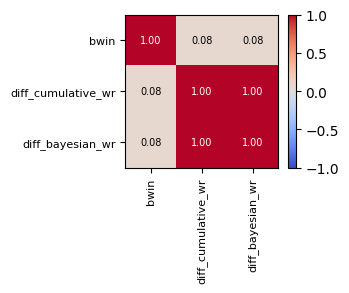


=== Model: group_cols=['championId'], prior=50 ===
Train size : 636,351
Test size  : 159,088
Accuracy   : 0.5359
AUC        : 0.5490
Brier      : 0.2482


In [48]:
# Comment to execute faster
games_df, model = build_and_evaluate(thin_df, group_cols=['championId'], prior_games=50)

=== Correlations with win (player level) ===
win                 1.0000
cumulative_wr       0.0246
bayesian_wr         0.0274
cumulative_games    0.0062
cumulative_wins     0.0068
Name: win, dtype: float64


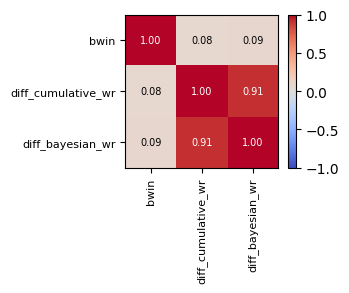


=== Model: group_cols=['championId', 'teamPosition'], prior=40 ===
Train size : 636,351
Test size  : 159,088
Accuracy   : 0.5401
AUC        : 0.5566
Brier      : 0.2477


In [49]:
# Comment to execute faster
games_df, model = build_and_evaluate(thin_df, group_cols=['championId','teamPosition'], prior_games=40)

=== Correlations with win (player level) ===
win                 1.0000
cumulative_wr       0.0002
bayesian_wr        -0.0015
cumulative_games    0.0027
cumulative_wins     0.0014
Name: win, dtype: float64


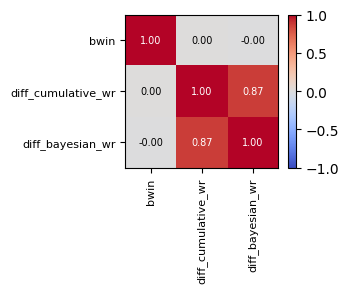


=== Model: group_cols=['puuid', 'teamPosition'], prior=5 ===
Train size : 636,351
Test size  : 159,088
Accuracy   : 0.5075
AUC        : 0.5069
Brier      : 0.2499


In [50]:
# Comment to execute faster
games_df, model = build_and_evaluate(thin_df, group_cols=['puuid','teamPosition'], prior_games=5)

=== Correlations with win (player level) ===
win                 1.0000
cumulative_wr       0.0049
bayesian_wr         0.0054
cumulative_games    0.0051
cumulative_wins     0.0055
Name: win, dtype: float64


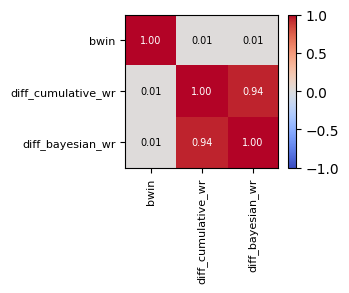


=== Model: group_cols=['puuid', 'championId', 'teamPosition'], prior=2 ===
Train size : 636,351
Test size  : 159,088
Accuracy   : 0.5056
AUC        : 0.5031
Brier      : 0.2500


In [51]:
# Comment to execute faster
games_df, model = build_and_evaluate(thin_df, group_cols=['puuid','championId','teamPosition'], prior_games=2)

## Module 3 New Features

### 2 - First Synergy Implementation (too much memory)
This was my original try using pandas merge. I used this before signing up for colab pro and it blew 16GB up pretty quickly. Pro has 51GB and it ran but was quite slow.


In [52]:

'''
# Add temporary columns for team and slot number to thin_df
thin_df['temp_team'] = thin_df['player_slot'].str[0]
thin_df['temp_slot_num'] = thin_df['player_slot'].str[1].astype(int)

synergy_thin_df = pd.merge(
    thin_df,
    thin_df,
    on=['gameId', 'temp_team'], # Merge on gameId AND the extracted team for efficiency
    suffixes=('_p1', '_p2')
)

# Now, filter based on the slot numbers
synergy_thin_df = synergy_thin_df[
    (synergy_thin_df['temp_slot_num_p1'] < synergy_thin_df['temp_slot_num_p2'])
].reset_index(drop=True)

# Drop the temporary columns created for the merge from synergy_thin_df
# 'temp_team' was a merge key, so it doesn't have a _p1/_p2 suffix
synergy_thin_df = synergy_thin_df.drop(columns=[
    'temp_team',
    'temp_slot_num_p1', 'temp_slot_num_p2'
])

# Remove the temporary columns from the original thin_df to revert its state
thin_df = thin_df.drop(columns=['temp_team', 'temp_slot_num'])

print(synergy_thin_df.head())
print(f"Number of rows in synergy_thin_df: {len(synergy_thin_df)}")
'''

'\n# Add temporary columns for team and slot number to thin_df\nthin_df[\'temp_team\'] = thin_df[\'player_slot\'].str[0]\nthin_df[\'temp_slot_num\'] = thin_df[\'player_slot\'].str[1].astype(int)\n\nsynergy_thin_df = pd.merge(\n    thin_df,\n    thin_df,\n    on=[\'gameId\', \'temp_team\'], # Merge on gameId AND the extracted team for efficiency\n    suffixes=(\'_p1\', \'_p2\')\n)\n\n# Now, filter based on the slot numbers\nsynergy_thin_df = synergy_thin_df[\n    (synergy_thin_df[\'temp_slot_num_p1\'] < synergy_thin_df[\'temp_slot_num_p2\'])\n].reset_index(drop=True)\n\n# Drop the temporary columns created for the merge from synergy_thin_df\n# \'temp_team\' was a merge key, so it doesn\'t have a _p1/_p2 suffix\nsynergy_thin_df = synergy_thin_df.drop(columns=[\n    \'temp_team\',\n    \'temp_slot_num_p1\', \'temp_slot_num_p2\'\n])\n\n# Remove the temporary columns from the original thin_df to revert its state\nthin_df = thin_df.drop(columns=[\'temp_team\', \'temp_slot_num\'])\n\nprint(sy

### 2 - Final Synergy Implementation
This was AI assisted as I was looking for a much more efficient implementation. It worked much better than the pure pandas version.

#### Order doesn't matter
AND then after thinking about it for a long time I realized that my algorithm won't work properly because order doesn't matter when calculating win/loss. For champion pair A,B I also need to consider the results of pair B,A. To solve this problem I created an ordered list for the champion pair so that when grouping they aggregate together regardless of the original order.

In [53]:
# Add temporary columns
thin_df = thin_df.assign(
    temp_team=thin_df['player_slot'].str[0],
    temp_slot_num=thin_df['player_slot'].str[1].astype(int)
)

# Keep all p1 columns
p1_df = thin_df

# Keep ONLY the p2 columns you actually need
p2_keep_cols = [
    'gameId',
    'temp_team',
    'temp_slot_num',
    'player_slot',
    'puuid',
    'championId'
]

p2_df = thin_df[p2_keep_cols]

synergy_thin_df = pd.merge(
    p1_df,
    p2_df,
    on=['gameId', 'temp_team'],
    suffixes=('_A', '_B')
)

# Filter to unique same-team pairs
synergy_thin_df = synergy_thin_df[
    synergy_thin_df['temp_slot_num_A'] < synergy_thin_df['temp_slot_num_B']
].reset_index(drop=True)

# Drop temporary columns
synergy_thin_df = synergy_thin_df.drop(columns=[
    'temp_team',
    'temp_slot_num_A',
    'temp_slot_num_B'
])

# Add in a two columns representing a fixed ordered pair or champions
synergy_thin_df['champion_pair_1'] = synergy_thin_df[
    ['championId_A', 'championId_B']
].min(axis=1)

synergy_thin_df['champion_pair_2'] = synergy_thin_df[
    ['championId_A', 'championId_B']
].max(axis=1)

# Remove temp columns from original thin_df
thin_df = thin_df.drop(columns=['temp_team', 'temp_slot_num'])

print(synergy_thin_df.head(10))
print(f"Number of rows in synergy_thin_df: {len(synergy_thin_df)}")

       gameId   gameCreation gameCreationDate  patch      tier  \
0  5576347036  1780789359000       2026-06-06   1611  Bronze I   
1  5576347036  1780789359000       2026-06-06   1611  Bronze I   
2  5576347036  1780789359000       2026-06-06   1611  Bronze I   
3  5576347036  1780789359000       2026-06-06   1611  Bronze I   
4  5576347036  1780789359000       2026-06-06   1611  Bronze I   
5  5576347036  1780789359000       2026-06-06   1611  Bronze I   
6  5576347036  1780789359000       2026-06-06   1611  Bronze I   
7  5576347036  1780789359000       2026-06-06   1611  Bronze I   
8  5576347036  1780789359000       2026-06-06   1611  Bronze I   
9  5576347036  1780789359000       2026-06-06   1611  Bronze I   

                                             puuid_A player_slot_A  \
0  kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...            r4   
1  LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...            r3   
2  LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...           

In [54]:
# Originally this grouped by ChampionId_A and ChampionId_B but that didn't account for
# the order not mattering so I had to change the code to match up with the fixed ordered pair
# champion_pair_1 and champion_pair_2

pair_wr_df = (
    synergy_thin_df
    .groupby(['patch', 'gameCreationDate', 'champion_pair_1', 'champion_pair_2'])['win']
    .agg(games='size', wins='sum')
    .reset_index()
    .sort_values(by=['patch', 'champion_pair_1', 'champion_pair_2', 'gameCreationDate'])
)

In [55]:
pair_wr_df['cumulative_games'] = (
    pair_wr_df.groupby(['patch', 'champion_pair_1', 'champion_pair_2'])['games'].cumsum()
)

pair_wr_df['cumulative_wins'] = (
    pair_wr_df.groupby(['patch', 'champion_pair_1', 'champion_pair_2'])['wins'].cumsum()
)

pair_wr_df['cumulative_wr'] = pair_wr_df['cumulative_wins'] / pair_wr_df['cumulative_games']

**Bayesian win rate** solves this by shrinking the estimate toward a prior — the global average
win rate across all champions — when sample size is small. As evidence accumulates, the estimate
converges to the empirical rate.

The formula is:

$$\hat{p} = \frac{\text{cumulative wins} + \alpha \cdot \mu}{\text{cumulative games} + \alpha}$$

Where:
- $\mu$ is the global prior win rate (roughly 0.5)
- $\alpha$ is the strength of the prior — how many "ghost games" worth of evidence to add
- When `cumulative_games` is small, the estimate stays close to $\mu$
- When `cumulative_games` is large, the estimate converges to the empirical rate

#### Alpha Justification
Because the feature is already narrow and sparse, a very large alpha may over-smooth it toward 0.5 and erase what little signal exists. I chose alpha = 10 to allow observed pair outcomes to influence the estimate once a pair has appeared several times, while still avoiding extreme 0% or 100% raw win rates.

In [56]:
pair_wr_df.head()

,patch,gameCreationDate,champion_pair_1,champion_pair_2,games,wins,cumulative_games,cumulative_wins,cumulative_wr
0,1610,2026-05-13,1,2,12,9,12,9,0.750000
14356,1610,2026-05-14,1,2,26,12,38,21,0.552632
28945,1610,2026-05-15,1,2,23,7,61,28,0.459016
43512,1610,2026-05-16,1,2,25,16,86,44,0.511628
58087,1610,2026-05-17,1,2,14,7,100,51,0.510000


In [57]:
# Build simplified leakage-safe pair_wr_df
# One row = one unordered champion pair on one date within one patch.
# Stats use only games BEFORE that date.

prior_games = 10
prior_wr = 0.5

pair_group_cols = ['patch', 'champion_pair_1', 'champion_pair_2']

# Copy to make it rerunable (uses RAM but worth it)
synergy_wr_df = pair_wr_df.copy()

synergy_wr_df['gameCreationDate'] = pd.to_datetime(synergy_wr_df['gameCreationDate'])
synergy_wr_df['patch'] = synergy_wr_df['patch'].astype(int)

# Sort so 'previous' means the previous observed date for this pair within this patch.
# This handles gaps: it is not a one-calendar-day shift.
synergy_wr_df = synergy_wr_df.sort_values(
    pair_group_cols + ['gameCreationDate']
).reset_index(drop=True)

# Previous history only.
# This shifts to the previous observed date for the pair, not the previous calendar day.
synergy_wr_df['cumulative_games'] = (
    synergy_wr_df
    .groupby(pair_group_cols)['games']
    .transform(lambda s: s.cumsum().shift(1))
    .fillna(0)
)

synergy_wr_df['cumulative_wins'] = (
    synergy_wr_df
    .groupby(pair_group_cols)['wins']
    .transform(lambda s: s.cumsum().shift(1))
    .fillna(0)
)

synergy_wr_df['bayesian_wr'] = (
    (synergy_wr_df['cumulative_wins'] + prior_games * prior_wr) /
    (synergy_wr_df['cumulative_games'] + prior_games)
)

synergy_wr_df = synergy_wr_df[
    [
        'patch',
        'gameCreationDate',
        'champion_pair_1',
        'champion_pair_2',
        'cumulative_games',
        'cumulative_wins',
        'bayesian_wr'
    ]
]

synergy_wr_df.head()

,patch,gameCreationDate,champion_pair_1,champion_pair_2,cumulative_games,cumulative_wins,bayesian_wr
0,1610,2026-05-13,1,2,0.0,0.0,0.500000
1,1610,2026-05-14,1,2,12.0,9.0,0.636364
2,1610,2026-05-15,1,2,38.0,21.0,0.541667
3,1610,2026-05-16,1,2,61.0,28.0,0.464789
4,1610,2026-05-17,1,2,86.0,44.0,0.510417


I shifted the cumulative pair totals within each patch/pair group so that the statistics for a given date only use games from prior observed dates. This avoids leakage because the pair's games on the current date are not included in the feature values for that date. The shift is by previous observation within the pair, not by one calendar day, so it still handles gaps where a champion pair does not appear every day.

### 3 - Counter implementation
I'm choosing to calculate the wins both directions. A beating B from blue to red is the same as A beating B from red to blue. We need to tally up both events.

This took several iterations in order to get something that was RAM efficient. My first implementation did a cross join and then eliminated the duplicates. This blew up multiple times.

This new version creates blue to red then reverses it for red to blue.

Having both directions with an appropriate direction win allows an easy join when we go back to the base data. Just join by date and champions.


In [58]:
# Keep only columns needed for counter features
counter_base_cols = [
    'gameId',
    'gameCreationDate',
    'patch',
    'player_slot',
    'championId',
    'bwin'
]

counter_base = thin_df[counter_base_cols].copy()

counter_base['temp_team'] = counter_base['player_slot'].str[0]

blue_df = counter_base[counter_base['temp_team'] == 'b'].copy()
red_df  = counter_base[counter_base['temp_team'] == 'r'].copy()

# Keep blue/red columns minimal before merge
blue_df = blue_df[
    ['gameId', 'gameCreationDate', 'patch', 'player_slot', 'championId', 'bwin']
]

red_df = red_df[
    ['gameId', 'player_slot', 'championId']
]

blue_red_pairs = pd.merge(
    blue_df,
    red_df,
    on='gameId',
    suffixes=('_blue', '_red')
)

# Direction 1: blue champion facing red champion
blue_direction = blue_red_pairs.rename(columns={
    'player_slot_blue': 'player_slot_A',
    'championId_blue': 'championId_A',
    'player_slot_red': 'player_slot_B',
    'championId_red': 'championId_B'
})

blue_direction['win_A'] = blue_direction['bwin']

blue_direction = blue_direction[
    [
        'gameId',
        'gameCreationDate',
        'patch',
        'player_slot_A',
        'championId_A',
        'player_slot_B',
        'championId_B',
        'win_A'
    ]
]

# Direction 2: red champion facing blue champion
red_direction = blue_red_pairs.rename(columns={
    'player_slot_red': 'player_slot_A',
    'championId_red': 'championId_A',
    'player_slot_blue': 'player_slot_B',
    'championId_blue': 'championId_B'
})

red_direction['win_A'] = 1 - red_direction['bwin']

red_direction = red_direction[
    [
        'gameId',
        'gameCreationDate',
        'patch',
        'player_slot_A',
        'championId_A',
        'player_slot_B',
        'championId_B',
        'win_A'
    ]
]

counter_thin_df = pd.concat(
    [blue_direction, red_direction],
    ignore_index=True
)

print(counter_thin_df.head(10))
print(f"Number of rows in counter_thin_df: {len(counter_thin_df)}")

       gameId gameCreationDate  patch player_slot_A  championId_A  \
0  5576347036       2026-06-06   1611            b5            57   
1  5576347036       2026-06-06   1611            b5            57   
2  5576347036       2026-06-06   1611            b5            57   
3  5576347036       2026-06-06   1611            b5            57   
4  5576347036       2026-06-06   1611            b5            57   
5  5576347036       2026-06-06   1611            b4           222   
6  5576347036       2026-06-06   1611            b4           222   
7  5576347036       2026-06-06   1611            b4           222   
8  5576347036       2026-06-06   1611            b4           222   
9  5576347036       2026-06-06   1611            b4           222   

  player_slot_B  championId_B  win_A  
0            r5           201      1  
1            r4            51      1  
2            r3            39      1  
3            r2            54      1  
4            r1             6      1  
5     

In [59]:
counter_thin_df.describe()

,gameId,gameCreationDate,patch,championId_A,championId_B,win_A
count,3.977195e+07,39771950,3.977195e+07,3.977195e+07,3.977195e+07,39771950.0
mean,5.568012e+09,2026-05-25 06:51:58.377618432,1.610396e+03,1.881643e+02,1.881643e+02,0.5
min,5.559428e+09,2026-05-13 00:00:00,1.610000e+03,1.000000e+00,1.000000e+00,0.0
25%,5.563772e+09,2026-05-19 00:00:00,1.610000e+03,4.500000e+01,4.500000e+01,0.0
50%,5.568184e+09,2026-05-25 00:00:00,1.610000e+03,9.900000e+01,9.900000e+01,0.5
75%,5.572347e+09,2026-05-31 00:00:00,1.611000e+03,2.220000e+02,2.220000e+02,1.0
max,5.576347e+09,2026-06-06 00:00:00,1.611000e+03,9.500000e+02,9.500000e+02,1.0
std,4.908400e+06,NaN,4.891221e-01,2.411684e+02,2.411684e+02,0.5


In [60]:
pair_wr_df = (
    counter_thin_df
    .groupby(['patch', 'gameCreationDate', 'championId_A', 'championId_B'])['win_A']
    .agg(games='size', wins_A='sum')
    .reset_index()
    .sort_values(by=['patch', 'championId_A', 'championId_B', 'gameCreationDate'])
)

In [61]:
pair_wr_df

,patch,gameCreationDate,championId_A,championId_B,games,wins_A
0,1610,2026-05-13,1,2,4,2
29328,1610,2026-05-14,1,2,25,22
58738,1610,2026-05-15,1,2,10,3
88130,1610,2026-05-16,1,2,12,6
117534,1610,2026-05-17,1,2,19,12
...,...,...,...,...,...,...
646711,1611,2026-06-02,950,910,66,36
676117,1611,2026-06-03,950,910,69,39
705521,1611,2026-06-04,950,910,49,29
734933,1611,2026-06-05,950,910,59,35


In [62]:
pair_wr_df['cumulative_games'] = (
    pair_wr_df.groupby(['patch', 'championId_A', 'championId_B'])['games'].cumsum()
)

pair_wr_df['cumulative_wins'] = (
    pair_wr_df.groupby(['patch', 'championId_A', 'championId_B'])['wins_A'].cumsum()
)

pair_wr_df['cumulative_wr'] = pair_wr_df['cumulative_wins'] / pair_wr_df['cumulative_games']

In [63]:
pair_wr_df

,patch,gameCreationDate,championId_A,championId_B,games,wins_A,cumulative_games,cumulative_wins,cumulative_wr
0,1610,2026-05-13,1,2,4,2,4,2,0.500000
29328,1610,2026-05-14,1,2,25,22,29,24,0.827586
58738,1610,2026-05-15,1,2,10,3,39,27,0.692308
88130,1610,2026-05-16,1,2,12,6,51,33,0.647059
117534,1610,2026-05-17,1,2,19,12,70,45,0.642857
...,...,...,...,...,...,...,...,...,...
646711,1611,2026-06-02,950,910,66,36,348,188,0.540230
676117,1611,2026-06-03,950,910,69,39,417,227,0.544365
705521,1611,2026-06-04,950,910,49,29,466,256,0.549356
734933,1611,2026-06-05,950,910,59,35,525,291,0.554286


In [64]:
# Max date in counter pair_wr_df
max_date = pair_wr_df['gameCreationDate'].max()

# Rows for A=1, B=2 and mirrored A=2, B=1 on the max date
mirror_check = pair_wr_df[
    (pair_wr_df['gameCreationDate'] == max_date) &
    (
        (
            (pair_wr_df['championId_A'] == 1) &
            (pair_wr_df['championId_B'] == 2)
        ) |
        (
            (pair_wr_df['championId_A'] == 2) &
            (pair_wr_df['championId_B'] == 1)
        )
    )
][
    [
        'patch',
        'gameCreationDate',
        'championId_A',
        'championId_B',
        'games',
        'wins_A',
        'cumulative_games',
        'cumulative_wins',
        'cumulative_wr'
    ]
].sort_values(['championId_A', 'championId_B'])

mirror_check

,patch,gameCreationDate,championId_A,championId_B,games,wins_A,cumulative_games,cumulative_wins,cumulative_wr
734934,1611,2026-06-06,1,2,16,7,180,82,0.455556
735105,1611,2026-06-06,2,1,16,9,180,98,0.544444


In [65]:
# Build simplified leakage-safe pair_wr_df
# One row = one unordered champion pair on one date within one patch.
# Stats use only games BEFORE that date.

prior_games = 10
prior_wr = 0.5

pair_group_cols = ['patch', 'championId_A', 'championId_B']

# Copy to make it rerunable (uses RAM but worth it)
counter_wr_df = pair_wr_df.copy()

counter_wr_df['gameCreationDate'] = pd.to_datetime(counter_wr_df['gameCreationDate'])
counter_wr_df['patch'] = counter_wr_df['patch'].astype(int)

# Sort so 'previous' means the previous observed date for this pair within this patch.
# This handles gaps: it is not a one-calendar-day shift.
counter_wr_df = counter_wr_df.sort_values(
    pair_group_cols + ['gameCreationDate']
).reset_index(drop=True)

# Previous history only.
# This shifts to the previous observed date for the pair, not the previous calendar day.
counter_wr_df['cumulative_games'] = (
    counter_wr_df
    .groupby(pair_group_cols)['games']
    .transform(lambda s: s.cumsum().shift(1))
    .fillna(0)
)

counter_wr_df['cumulative_wins_A'] = (
    counter_wr_df
    .groupby(pair_group_cols)['wins_A']
    .transform(lambda s: s.cumsum().shift(1))
    .fillna(0)
)

counter_wr_df['bayesian_wr'] = (
    (counter_wr_df['cumulative_wins_A'] + prior_games * prior_wr) /
    (counter_wr_df['cumulative_games'] + prior_games)
)

counter_wr_df = counter_wr_df[
    [
        'patch',
        'gameCreationDate',
        'championId_A',
        'championId_B',
        'cumulative_games',
        'cumulative_wins_A',
        'bayesian_wr'
    ]
]

counter_wr_df.head()

,patch,gameCreationDate,championId_A,championId_B,cumulative_games,cumulative_wins_A,bayesian_wr
0,1610,2026-05-13,1,2,0.0,0.0,0.500000
1,1610,2026-05-14,1,2,4.0,2.0,0.500000
2,1610,2026-05-15,1,2,29.0,24.0,0.743590
3,1610,2026-05-16,1,2,39.0,27.0,0.653061
4,1610,2026-05-17,1,2,51.0,33.0,0.622951


### Get Synergy and Counter Ready to Use

#### GameId and Synergy wr

In [66]:
# Add only leakage-safe Bayesian synergy WR to synergy_thin_df

synergy_thin_df = synergy_thin_df.merge(
    synergy_wr_df[
        [
            'patch',
            'gameCreationDate',
            'champion_pair_1',
            'champion_pair_2',
            'bayesian_wr'
        ]
    ],
    on=[
        'patch',
        'gameCreationDate',
        'champion_pair_1',
        'champion_pair_2'
    ],
    how='left'
)

synergy_thin_df.head()

,gameId,gameCreation,gameCreationDate,patch,tier,puuid_A,player_slot_A,teamPosition,championId_A,leaguePoints,mpoints,win,bwin,player_slot_B,puuid_B,championId_B,champion_pair_1,champion_pair_2,bayesian_wr
0,5576347036,1780789359000,2026-06-06,1611,Bronze I,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,r4,BOTTOM,51,1140.0,53620.0,0,1,r5,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,201,51,201,0.491765
1,5576347036,1780789359000,2026-06-06,1611,Bronze I,LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...,r3,MIDDLE,39,838.0,25590.0,0,1,r5,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,201,39,201,0.506536
2,5576347036,1780789359000,2026-06-06,1611,Bronze I,LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...,r3,MIDDLE,39,838.0,25590.0,0,1,r4,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,51,39,51,0.479369
3,5576347036,1780789359000,2026-06-06,1611,Bronze I,3JHxmwD0ISAgOfCHQiphzSkAEqrCYvLFTjaMAXR10JJYn_...,r2,JUNGLE,54,773.0,26785.0,0,1,r5,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,201,54,201,0.503797
4,5576347036,1780789359000,2026-06-06,1611,Bronze I,3JHxmwD0ISAgOfCHQiphzSkAEqrCYvLFTjaMAXR10JJYn_...,r2,JUNGLE,54,773.0,26785.0,0,1,r4,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,51,51,54,0.490829


In [67]:
# Calculate average synergy bayesian win rate for each game
# Average synergy Bayesian WR by game and team
synergy_game_avg_wr = (
    synergy_thin_df
    .assign(team=synergy_thin_df['player_slot_A'].str[0])
    .groupby(['gameId', 'team'])['bayesian_wr']
    .mean()
    .reset_index()
)
synergy_game_avg_wr

,gameId,team,bayesian_wr
0,5559427826,b,0.500000
1,5559427826,r,0.500000
2,5559427860,b,0.500000
3,5559427860,r,0.500000
4,5559427862,b,0.500000
...,...,...,...
1590873,5576346837,r,0.516189
1590874,5576346899,b,0.513043
1590875,5576346899,r,0.505078
1590876,5576347036,b,0.531051


#### GameId and Counter wr
I did the naive thing first and grouped them by gameId and averaged. They were all 0.5 because yep - either blue or red wins and it's a zero sum game.

In [68]:
counter_thin_df = counter_thin_df.drop(
    columns=['bayesian_wr'],
    errors='ignore'
)

counter_thin_df = counter_thin_df.merge(
    counter_wr_df[
        [
            'patch',
            'gameCreationDate',
            'championId_A',
            'championId_B',
            'bayesian_wr'
        ]
    ],
    on=[
        'patch',
        'gameCreationDate',
        'championId_A',
        'championId_B'
    ],
    how='left'
)


In [69]:
# Blue-side counter strength:
# rows where championId_A is the blue champion facing a red champion
# Average counter Bayesian WR by game and team
# team = side of championId_A

counter_game_avg_wr = (
    counter_thin_df
    .assign(team=counter_thin_df['player_slot_A'].str[0])
    .groupby(['gameId', 'team'])['bayesian_wr']
    .mean()
    .reset_index()
    .rename(columns={'bayesian_wr': 'counter_bayesian_wr'})
)

counter_game_avg_wr

,gameId,team,counter_bayesian_wr
0,5559427826,b,0.500000
1,5559427826,r,0.500000
2,5559427860,b,0.500000
3,5559427860,r,0.500000
4,5559427862,b,0.500000
...,...,...,...
1590873,5576346837,r,0.499289
1590874,5576346899,b,0.493749
1590875,5576346899,r,0.506251
1590876,5576347036,b,0.506107


In [70]:
# Join synergy and counter features back to player-level thin_df

thin_features_df = thin_df.copy()

thin_features_df['team'] = thin_features_df['player_slot'].str[0]

# Rename synergy feature if needed
if 'bayesian_wr' in synergy_game_avg_wr.columns:
    synergy_game_avg_wr = synergy_game_avg_wr.rename(
        columns={'bayesian_wr': 'synergy_bayesian_wr'}
    )

thin_features_df = thin_features_df.merge(
    synergy_game_avg_wr,
    on=['gameId', 'team'],
    how='left'
)

thin_features_df = thin_features_df.merge(
    counter_game_avg_wr,
    on=['gameId', 'team'],
    how='left'
)

# Sanity checks
print(f"thin_df rows:          {len(thin_df):,}")
print(f"thin_features_df rows: {len(thin_features_df):,}")

assert len(thin_features_df) == len(thin_df)

print(
    thin_features_df[
        ['synergy_bayesian_wr', 'counter_bayesian_wr']
    ].isna().sum()
)

assert thin_features_df['synergy_bayesian_wr'].between(0, 1).all()
assert thin_features_df['counter_bayesian_wr'].between(0, 1).all()

print("Feature join sanity checks passed.")

thin_features_df.head()

thin_df rows:          7,954,390
thin_features_df rows: 7,954,390
synergy_bayesian_wr    0
counter_bayesian_wr    0
dtype: int64
Feature join sanity checks passed.


,gameId,gameCreation,gameCreationDate,patch,tier,puuid,player_slot,teamPosition,championId,leaguePoints,mpoints,win,bwin,team,synergy_bayesian_wr,counter_bayesian_wr
0,5576347036,1780789359000,2026-06-06,1611,Bronze I,ByDYA719_qm2VBMGK4SIvmBNQCeDM3KLpEqVtoW66sCkJY...,r5,UTILITY,201,317.0,551.0,0,1,r,0.50742,0.493893
1,5576347036,1780789359000,2026-06-06,1611,Bronze I,kCBzeYnrb5MGZLNWHASw9hjc1HhZywh-ohmRv3WGiA3pPY...,r4,BOTTOM,51,1140.0,53620.0,0,1,r,0.50742,0.493893
2,5576347036,1780789359000,2026-06-06,1611,Bronze I,LBQGHXMXgenD-tbW3UHWSMdmxlEVWkzLPTqWzBmeF1S6OW...,r3,MIDDLE,39,838.0,25590.0,0,1,r,0.50742,0.493893
3,5576347036,1780789359000,2026-06-06,1611,Bronze I,3JHxmwD0ISAgOfCHQiphzSkAEqrCYvLFTjaMAXR10JJYn_...,r2,JUNGLE,54,773.0,26785.0,0,1,r,0.50742,0.493893
4,5576347036,1780789359000,2026-06-06,1611,Bronze I,nYK1rHBtZJpVl24I8YqYeg53oV4rmoFn0GmBm6uVDIjVBw...,r1,TOP,6,733.0,56443.0,0,1,r,0.50742,0.493893


### 4 - Start to use the new features

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score

# Convert player-level/team-level features to one row per game
game_features_df = (
    thin_features_df
    .pivot_table(
        index=['gameId', 'gameCreation', 'patch', 'bwin'],
        columns='player_slot',
        values=['synergy_bayesian_wr', 'counter_bayesian_wr'],
        aggfunc='first'
    )
)

game_features_df.columns = [
    f'{slot}_{feature}' for feature, slot in game_features_df.columns
]

game_features_df = game_features_df.reset_index()

# Blue minus red feature differences
game_features_df['diff_synergy_bayesian_wr'] = (
    game_features_df[[f'b{i}_synergy_bayesian_wr' for i in range(1, 6)]].mean(axis=1) -
    game_features_df[[f'r{i}_synergy_bayesian_wr' for i in range(1, 6)]].mean(axis=1)
)

game_features_df['diff_counter_bayesian_wr'] = (
    game_features_df[[f'b{i}_counter_bayesian_wr' for i in range(1, 6)]].mean(axis=1) -
    game_features_df[[f'r{i}_counter_bayesian_wr' for i in range(1, 6)]].mean(axis=1)
)

feature_cols = [
    'diff_synergy_bayesian_wr',
    'diff_counter_bayesian_wr'
]

# Same kind of temporal split by patch that build_and_evaluate uses
cutoffs = game_features_df.groupby('patch')['gameCreation'].quantile(0.8)
game_features_df['cutoff'] = game_features_df['patch'].map(cutoffs)

train = game_features_df[game_features_df['gameCreation'] <= game_features_df['cutoff']]
test = game_features_df[game_features_df['gameCreation'] > game_features_df['cutoff']]

X_train = train[feature_cols].fillna(0)
y_train = train['bwin']

X_test = test[feature_cols].fillna(0)
y_test = test['bwin']

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(f"Train size : {len(X_train):,}")
print(f"Test size  : {len(X_test):,}")
print(f"Accuracy   : {accuracy_score(y_test, preds):.4f}")
print(f"AUC        : {roc_auc_score(y_test, proba):.4f}")
print(f"Brier      : {brier_score_loss(y_test, proba):.4f}")

Train size : 636,351
Test size  : 159,088
Accuracy   : 0.5393
AUC        : 0.5553
Brier      : 0.2478


#### Model discussion

In this model I created two features one for the Blue - Red Synergy Bayesian win rate difference and the other the Counter Bayesian win rate difference. I then created a logistic regresssion model and tested it createing the same model metrics of Accuracy, AUC, and Brier score. The model isn't great - 53.93% accuracy, AUC of 0.5553, and Brier of 0.2478 but it is somewhat beater than the baseline.

| Model                          | Features Used                                                    | Accuracy | AUC    | Brier  |
|--------------------------------|------------------------------------------------------------------|----------|--------|--------|
| Champion win rate model        | Champion historical Bayesian win rate                            | 0.5359   | 0.5490 | 0.2482 |
| Champion + role model          | Champion and team-position historical Bayesian win rate          | 0.5401   | 0.5566 | 0.2477 |
| Player + role model            | Player and team-position historical Bayesian win rate            | 0.5075   | 0.5069 | 0.2499 |
| Player + champion + role model | Player/champion/team-position historical Bayesian win rate       | 0.5056   | 0.5031 | 0.2500 |
| My model                      | Blue-minus-red synergy and counter Bayesian win rate differences | 0.5393   | 0.5553 | 0.2478 |

If I'm working at Riot games, synergy and counter seem like reasonable features to add. Just used by themselves they seem like decent predictors. As I discuss below in my notes, there is a good bit of overhead required in calculation. RAM usage in particular is high but also compute time. Also, if we're running in production we'd probably want to use all available data. I tried doing this and it will still run (probably not for much longer) on my 51GB RAM instance but it was tight.

### 5 - Interpretation

#### Sparsity

In [72]:
# Sparsity evidence for Part 5

champion_counts = (
    thin_df
    .groupby(['patch', 'championId'])
    .size()
    .reset_index(name='games')
)

synergy_pair_counts = (
    synergy_wr_df
    .groupby(['patch', 'champion_pair_1', 'champion_pair_2'])
    ['cumulative_games']
    .max()
    .reset_index(name='games')
)

counter_pair_counts = (
    counter_wr_df
    .groupby(['patch', 'championId_A', 'championId_B'])
    ['cumulative_games']
    .max()
    .reset_index(name='games')
)

sparsity_summary = pd.DataFrame({
    'feature_type': ['individual_champion', 'synergy_pair', 'counter_pair'],
    'num_entities': [
        len(champion_counts),
        len(synergy_pair_counts),
        len(counter_pair_counts)
    ],
    'median_games': [
        champion_counts['games'].median(),
        synergy_pair_counts['games'].median(),
        counter_pair_counts['games'].median()
    ],
    'mean_games': [
        champion_counts['games'].mean(),
        synergy_pair_counts['games'].mean(),
        counter_pair_counts['games'].mean()
    ],
    'pct_under_10_games': [
        (champion_counts['games'] < 10).mean(),
        (synergy_pair_counts['games'] < 10).mean(),
        (counter_pair_counts['games'] < 10).mean()
    ],
    'pct_under_50_games': [
        (champion_counts['games'] < 50).mean(),
        (synergy_pair_counts['games'] < 50).mean(),
        (counter_pair_counts['games'] < 50).mean()
    ]
})

sparsity_summary

,feature_type,num_entities,median_games,mean_games,pct_under_10_games,pct_under_50_games
0,individual_champion,344,18359.5,23123.226744,0.000000,0.000000
1,synergy_pair,29403,317.0,509.235078,0.009183,0.055266
2,counter_pair,58824,421.0,636.392323,0.000000,0.005916


We would expect that paired occurences would be significantly less than individuals. This is supported by the table above. Synergy and Counter have 29K and 59K entities respectively with much fewer games per entitiy than for individual champions.

The Bayesian smoothing is important particularly for the paired features and moreso early in the dataset. Without the smoothing we'd see 0% and 100% win rates with potentially wide swings in the win rate based on each additional day's performance. This would introduce a lot of noise into the model training during the first few days of the dataset and with each subsequent patch.

### Notes on the assignment
1. AI disclosure - I used AI a lot for code generation. The logic is mine but I got tied up in the code and needed quite a bit of help to get the syntax straight. I also used AI to optimize my code as what I had at first was using A LOT of memory just to create the synergy pairs.
2. I'm currently using a colab pro high-RAM instance. It's got 51GB of RAM but that's not going to be enough in a couple of weeks.
3. I didn't fully understand the modeling task. I chose to combine synergy and counter into a single model. I could break them out in future assignments if needed.
4. This was A LOT of work! I learned a lot. I've thought about the algorithms and the data so much that I'm starting to dream about it...